The dataset contains all available data for more than 800,000 consumer loans issued from 2007 to 2015 by Lending Club: a large US peer-to-peer lending company. There are several different versions of this dataset. We have used a version available on kaggle.com.https://www.kaggle.com/wendykan/lending-club-loan-data/version/1

# Data Preparation

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

## Import Data

In [2]:
loan_data = pd.read_csv('loan_data_2007_2014.csv')

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3147310615.py:1: DtypeWarning: Columns (0: desc) have mixed types. Specify dtype option on import or set low_memory=False.
  loan_data = pd.read_csv('loan_data_2007_2014.csv')


## Explore Data

In [3]:
pd.options.display.max_columns = None

In [4]:
loan_data

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.00,0.00,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.00,0.00,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.00,0.00,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.00,0.00,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.90,766.90,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,466280,8598660,1440975,18400,18400,18400.0,60 months,14.47,432.64,C,C2,Financial Advisor,4 years,MORTGAGE,110000.0,Source Verified,Jan-14,Current,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt consolidation,773

In [5]:
loan_data.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
loan_data.columns.values

<StringArray>
[                 'Unnamed: 0',                          'id',
                   'member_id',                   'loan_amnt',
                 'funded_amnt',             'funded_amnt_inv',
                        'term',                    'int_rate',
                 'installment',                       'grade',
                   'sub_grade',                   'emp_title',
                  'emp_length',              'home_ownership',
                  'annual_inc',         'verification_status',
                     'issue_d',                 'loan_status',
                  'pymnt_plan',                         'url',
                        'desc',                     'purpose',
                       'title',                    'zip_code',
                  'addr_state',                         'dti',
                 'delinq_2yrs',            'earliest_cr_line',
              'inq_last_6mths',      'mths_since_last_delinq',
      'mths_since_last_record',          

In [7]:
loan_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  str    
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  str    
 10  sub_grade                    466285 non-null  str    
 11  emp_title                    438697 non-null  str    
 12  emp_length                   445277 non-null  str    
 13  home_owner

# PREPROCESSING ON CONTINUOUS VAR

EMP_length

In [8]:
loan_data['emp_length'].unique()

<StringArray>
['10+ years',  '< 1 year',    '1 year',   '3 years',   '8 years',   '9 years',
   '4 years',   '5 years',   '6 years',   '2 years',   '7 years',         nan]
Length: 12, dtype: str

In [9]:
### removing strings from emp_length values and converting it to numeric
loan_data['emp_length_int'] = loan_data['emp_length'].str.replace('10+ years', '10', regex=False)
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace('< 1 year', str(0), regex=False)
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace('n/a', str(0), regex=False)
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace(' years', '', regex=False)
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace(' year', '', regex=False)


In [10]:
loan_data['emp_length_int'] = pd.to_numeric(loan_data['emp_length_int'])
type(loan_data['emp_length_int'][0])

numpy.float64

In [11]:
loan_data['earliest_cr_line']

0         Jan-85
1         Apr-99
2         Nov-01
3         Feb-96
4         Jan-96
           ...  
466280    Apr-03
466281    Jun-97
466282    Dec-01
466283    Feb-03
466284    Feb-00
Name: earliest_cr_line, Length: 466285, dtype: str

In [12]:
### converting earliest_cr_line_date into datetime
loan_data['earliest_cr_line_date'] = pd.to_datetime(loan_data['earliest_cr_line'], format = '%b-%y')

In [13]:
loan_data['earliest_cr_line_date'][0]

Timestamp('1985-01-01 00:00:00')

In [14]:
## converted earlies_cr_line column into days using todays date
days_earliest_cr_line = pd.to_datetime('2026-03-25') - loan_data['earliest_cr_line_date']


In [15]:
## convert days to months
loan_data['mths_since_earliest_cr_line'] = round(pd.to_numeric(days_earliest_cr_line / np.timedelta64(1, 'D')) / 30.4375)


In [16]:
loan_data['mths_since_earliest_cr_line'].describe()
## min value is -549 which is impossible......months since earliest credit line cannot be less than zero

count    466256.000000
mean        339.482430
std          93.974829
min        -512.000000
25%         283.000000
50%         325.000000
75%         385.000000
max         687.000000
Name: mths_since_earliest_cr_line, dtype: float64

In [17]:
loan_data.loc[: , ['earliest_cr_line', 'earliest_cr_line_date', 'mths_since_earliest_cr_line']][loan_data['mths_since_earliest_cr_line'] < 0]
## issue is with datetime function...... it could not interpret 1960, 1970 period and termed it as 2060,2070

,earliest_cr_line,earliest_cr_line_date,mths_since_earliest_cr_line
1580,Sep-62,2062-09-01,-437.0
1770,Sep-68,2068-09-01,-509.0
2799,Sep-64,2064-09-01,-461.0
3282,Sep-67,2067-09-01,-497.0
3359,Feb-65,2065-02-01,-466.0
...,...,...,...
464003,Jan-68,2068-01-01,-501.0
464260,Jul-66,2066-07-01,-483.0
465100,Oct-67,2067-10-01,-498.0
465500,Sep-67,2067-09-01,-497.0


In [18]:
loan_data['mths_since_earliest_cr_line'][loan_data['mths_since_earliest_cr_line'] < 0] = loan_data['mths_since_earliest_cr_line'].max()
##there are only 1169 rows with such entries so we just modify them by replacing it with max value

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2448096214.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  loan_data['mths_since_earliest_cr_line'][loan_data['mths_since_earliest_cr_line'] < 0] = loan_data['mths_since_earliest_cr_line'].max()


In [19]:
min(loan_data['mths_since_earliest_cr_line'])

-512.0

In [20]:
max(loan_data['mths_since_earliest_cr_line'])

687.0

In [21]:
loan_data['term'].describe()

count         466285
unique             2
top        36 months
freq          337953
Name: term, dtype: object

In [22]:
loan_data['term_int'] = loan_data['term'].str.replace(' months', '')

In [23]:
loan_data['term_int'] = pd.to_numeric(loan_data['term'].str.replace(' months', ''))
loan_data['term_int']

0         36
1         60
2         36
3         36
4         60
          ..
466280    60
466281    60
466282    60
466283    36
466284    36
Name: term_int, Length: 466285, dtype: int64

Issue_date

In [24]:
loan_data['issue_d']

0         Dec-11
1         Dec-11
2         Dec-11
3         Dec-11
4         Dec-11
           ...  
466280    Jan-14
466281    Jan-14
466282    Jan-14
466283    Jan-14
466284    Jan-14
Name: issue_d, Length: 466285, dtype: str

In [25]:
loan_data['issue_d_date'] = pd.to_datetime(loan_data['issue_d'], format = '%b-%y')
loan_data['mths_since_issue_d'] = round(pd.to_numeric((pd.to_datetime('2026-03-25') - loan_data['issue_d_date']) / np.timedelta64(1, 'D')) / 30.4375)
loan_data['mths_since_issue_d'].describe()


count    466285.000000
mean        151.255187
std          14.340154
min         136.000000
25%         141.000000
50%         147.000000
75%         157.000000
max         226.000000
Name: mths_since_issue_d, dtype: float64

# PREPROCESSING ON DISCRETE VAR

In [26]:
pd.get_dummies(loan_data['grade'], prefix = 'grade', prefix_sep = ':')

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G
0,False,True,False,False,False,False,False
1,False,False,True,False,False,False,False
2,False,False,True,False,False,False,False
3,False,False,True,False,False,False,False
4,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...
466280,False,False,True,False,False,False,False
466281,False,False,False,True,False,False,False
466282,False,False,False,True,False,False,False
466283,True,False,False,False,False,False,False


In [27]:
loan_data_dummies = [pd.get_dummies(loan_data['grade'], prefix = 'grade', prefix_sep = ':'),
                     pd.get_dummies(loan_data['sub_grade'], prefix = 'sub_grade', prefix_sep = ':'),
                     pd.get_dummies(loan_data['home_ownership'], prefix = 'home_ownership', prefix_sep = ':'),
                     pd.get_dummies(loan_data['verification_status'], prefix = 'verification_status', prefix_sep = ':'),
                     pd.get_dummies(loan_data['loan_status'], prefix = 'loan_status', prefix_sep = ':'),
                     pd.get_dummies(loan_data['purpose'], prefix = 'purpose', prefix_sep = ':'),
                     pd.get_dummies(loan_data['addr_state'], prefix = 'addr_state', prefix_sep = ':'),
                     pd.get_dummies(loan_data['initial_list_status'], prefix = 'initial_list_status', prefix_sep = ':')]

In [28]:
loan_data_dummies = pd.concat(loan_data_dummies, axis = 1)

In [29]:
loan_data_dummies

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,sub_grade:A1,sub_grade:A2,sub_grade:A3,sub_grade:A4,sub_grade:A5,sub_grade:B1,sub_grade:B2,sub_grade:B3,sub_grade:B4,sub_grade:B5,sub_grade:C1,sub_grade:C2,sub_grade:C3,sub_grade:C4,sub_grade:C5,sub_grade:D1,sub_grade:D2,sub_grade:D3,sub_grade:D4,sub_grade:D5,sub_grade:E1,sub_grade:E2,sub_grade:E3,sub_grade:E4,sub_grade:E5,sub_grade:F1,sub_grade:F2,sub_grade:F3,sub_grade:F4,sub_grade:F5,sub_grade:G1,sub_grade:G2,sub_grade:G3,sub_grade:G4,sub_grade:G5,home_ownership:ANY,home_ownership:MORTGAGE,home_ownership:NONE,home_ownership:OTHER,home_ownership:OWN,home_ownership:RENT,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,loan_status:Charged Off,loan_status:Current,loan_status:Default,loan_status:Does not meet the credit policy. Status:Charged Off,loan_status:Does not meet the credit policy. Status:Fully Paid,loan_status:Fully Paid,loan_status:In Grace Period,loan_status:Late (16-30 days),loan_status:Late (31-120 days),purpose:car,purpose:credit_card,purpose:debt_consolidation,purpose:educational,purpose:home_improvement,purpose:house,purpose:major_purchase,purpose:medical,purpose:moving,purpose:other,purpose:renewable_energy,purpose:small_business,purpose:vacation,purpose:wedding,addr_state:AK,addr_state:AL,addr_state:AR,addr_state:AZ,addr_state:CA,addr_state:CO,addr_state:CT,addr_state:DC,addr_state:DE,addr_state:FL,addr_state:GA,addr_state:HI,addr_state:IA,addr_state:ID,addr_state:IL,addr_state:IN,addr_state:KS,addr_state:KY,addr_state:LA,addr_state:MA,addr_state:MD,addr_state:ME,addr_state:MI,addr_state:MN,addr_state:MO,addr_state:MS,addr_state:MT,addr_state:NC,addr_state:NE,addr_state:NH,addr_state:NJ,addr_state:NM,addr_state:NV,addr_state:NY,addr_state:OH,addr_state:OK,addr_state:OR,addr_state:PA,addr_state:RI,addr_state:SC,addr_state:SD,addr_state:TN,addr_state:TX,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w
0,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,F

In [30]:
loan_data = pd.concat([loan_data, loan_data_dummies], axis = 1)

In [31]:
loan_data.columns.values

<StringArray>
[           'Unnamed: 0',                    'id',             'member_id',
             'loan_amnt',           'funded_amnt',       'funded_amnt_inv',
                  'term',              'int_rate',           'installment',
                 'grade',
 ...
         'addr_state:TX',         'addr_state:UT',         'addr_state:VA',
         'addr_state:VT',         'addr_state:WA',         'addr_state:WI',
         'addr_state:WV',         'addr_state:WY', 'initial_list_status:f',
 'initial_list_status:w']
Length: 207, dtype: str

# MISSING VALUES

In [32]:
loan_data.isnull().sum()

Unnamed: 0               0
id                       0
member_id                0
loan_amnt                0
funded_amnt              0
                        ..
addr_state:WI            0
addr_state:WV            0
addr_state:WY            0
initial_list_status:f    0
initial_list_status:w    0
Length: 207, dtype: int64

In [33]:
pd.options.display.max_rows = 100

In [34]:
loan_data['total_rev_hi_lim'].fillna(loan_data['funded_amnt'], inplace=True)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\4218518735.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  loan_data['total_rev_hi_lim'].fillna(loan_data['funded_amnt'], inplace=True)


0          5000.0
1          2500.0
2          2400.0
3         10000.0
4          3000.0
           ...   
466280    29900.0
466281    39400.0
466282    13100.0
466283    53100.0
466284    16000.0
Name: total_rev_hi_lim, Length: 466285, dtype: float64

In [35]:
loan_data['annual_inc'].fillna(loan_data['annual_inc'].mean(), inplace=True)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3358011822.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  loan_data['annual_inc'].fillna(loan_data['annual_inc'].mean(), inplace=True)


0          24000.0
1          30000.0
2          12252.0
3          49200.0
4          80000.0
            ...   
466280    110000.0
466281     78000.0
466282     46000.0
466283     83000.0
466284     46000.0
Name: annual_inc, Length: 466285, dtype: float64

In [36]:
loan_data['mths_since_earliest_cr_line'].fillna(0, inplace=True)
loan_data['acc_now_delinq'].fillna(0, inplace=True)
loan_data['total_acc'].fillna(0, inplace=True)
loan_data['pub_rec'].fillna(0, inplace=True)
loan_data['open_acc'].fillna(0, inplace=True)
loan_data['inq_last_6mths'].fillna(0, inplace=True)
loan_data['delinq_2yrs'].fillna(0, inplace=True)
loan_data['emp_length_int'].fillna(0, inplace=True)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3452305065.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  loan_data['mths_since_earliest_cr_line'].fillna(0, inplace=True)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3452305065.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through ch

0         10.0
1          0.0
2         10.0
3         10.0
4          1.0
          ... 
466280     4.0
466281    10.0
466282     7.0
466283     3.0
466284    10.0
Name: emp_length_int, Length: 466285, dtype: float64

In [37]:
# Save full preprocessed dataset for LGD and EAD modeling
loan_data.to_csv('loan_data_2007_2014_preprocessed.csv')


# PROBABILITY OF DEFAULT MODEL

Dependent Variable. Good/ Bad (Default) Definition. Default and Non-default Accounts.

In [38]:
loan_data['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [39]:
loan_data['good_bad'] = np.where(loan_data['loan_status'].isin(['Charged Off', 'Default',
                                                       'Does not meet the credit policy. Status:Charged Off',
                                                       'Late (31-120 days)']), 0, 1)

# Splitting Data

In [40]:
loan_data_inputs_train, loan_data_inputs_test, loan_data_targets_train, loan_data_targets_test = train_test_split(loan_data.drop('good_bad', axis = 1), loan_data['good_bad'], test_size = 0.2, random_state = 1,stratify = loan_data['good_bad'])

In [41]:
loan_data_inputs_train.shape

(373028, 207)

In [42]:
loan_data_targets_test.shape

(93257,)

In [43]:
df_inputs_prepr = loan_data_inputs_train
df_targets_prepr = loan_data_targets_train

In [44]:
df_inputs_prepr_test = loan_data_inputs_test
df_targets_test_prepr = loan_data_targets_test

In [45]:
loan_data_inputs_test.shape

(93257, 207)

In [46]:
df_inputs_prepr['grade'].unique()

<StringArray>
['D', 'B', 'C', 'G', 'A', 'E', 'F']
Length: 7, dtype: str

In [47]:
df1 = pd.concat([df_inputs_prepr['grade'], df_targets_prepr], axis = 1)
df1.head()

,grade,good_bad
167844,D,1
304337,B,1
355929,C,1
97687,G,1
62651,D,1


In [48]:
df1.groupby(df1.columns.values[0], as_index = False)[df1.columns.values[1]].count()

,grade,good_bad
0,A,59907
1,B,109604
2,C,99995
3,D,61522
4,E,28637
5,F,10683
6,G,2680


In [49]:
df1.groupby(df1.columns.values[0], as_index = False)[df1.columns.values[1]].mean()

,grade,good_bad
0,A,0.961056
1,B,0.921700
2,C,0.885104
3,D,0.845697
4,E,0.805182
5,F,0.760741
6,G,0.723134


In [50]:
df1 = pd.concat([df1.groupby(df1.columns.values[0], as_index = False)[df1.columns.values[1]].count(),
                df1.groupby(df1.columns.values[0], as_index = False)[df1.columns.values[1]].mean()], axis = 1)

In [51]:
df1 = df1.iloc[:, [0, 1, 3]]
df1

,grade,good_bad,good_bad
0,A,59907,0.961056
1,B,109604,0.921700
2,C,99995,0.885104
3,D,61522,0.845697
4,E,28637,0.805182
5,F,10683,0.760741
6,G,2680,0.723134


In [52]:
df1.columns = [df1.columns.values[0], 'n_obs', 'prop_good']

In [53]:
df1['prop_n_obs'] = df1['n_obs'] / df1['n_obs'].sum()
# We divide the values of one column by he values of another column and save the result in a new variable.
df1

,grade,n_obs,prop_good,prop_n_obs
0,A,59907,0.961056,0.160597
1,B,109604,0.921700,0.293822
2,C,99995,0.885104,0.268063
3,D,61522,0.845697,0.164926
4,E,28637,0.805182,0.076769
5,F,10683,0.760741,0.028639
6,G,2680,0.723134,0.007184


In [54]:
df1['n_good'] = df1['prop_good'] * df1['n_obs']
# We multiply the values of one column by he values of another column and save the result in a new variable.
df1['n_bad'] = (1 - df1['prop_good']) * df1['n_obs']
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad
0,A,59907,0.961056,0.160597,57574.0,2333.0
1,B,109604,0.921700,0.293822,101022.0,8582.0
2,C,99995,0.885104,0.268063,88506.0,11489.0
3,D,61522,0.845697,0.164926,52029.0,9493.0
4,E,28637,0.805182,0.076769,23058.0,5579.0
5,F,10683,0.760741,0.028639,8127.0,2556.0
6,G,2680,0.723134,0.007184,1938.0,742.0


In [55]:
df1['prop_n_good'] = df1['n_good'] / df1['n_good'].sum()
df1['prop_n_bad'] = df1['n_bad'] / df1['n_bad'].sum()
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad
0,A,59907,0.961056,0.160597,57574.0,2333.0,0.173283,0.057218
1,B,109604,0.921700,0.293822,101022.0,8582.0,0.304051,0.210477
2,C,99995,0.885104,0.268063,88506.0,11489.0,0.266381,0.281773
3,D,61522,0.845697,0.164926,52029.0,9493.0,0.156594,0.232820
4,E,28637,0.805182,0.076769,23058.0,5579.0,0.069399,0.136827
5,F,10683,0.760741,0.028639,8127.0,2556.0,0.024460,0.062687
6,G,2680,0.723134,0.007184,1938.0,742.0,0.005833,0.018198


In [56]:
df1['WoE'] = np.log(df1['prop_n_good'] / df1['prop_n_bad'])

In [57]:
df1 = df1.sort_values(['WoE'])

In [58]:
df1 = df1.reset_index(drop = True)
# We reset the index of a dataframe and overwrite it.
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE
0,G,2680,0.723134,0.007184,1938.0,742.0,0.005833,0.018198,-1.137793
1,F,10683,0.760741,0.028639,8127.0,2556.0,0.024460,0.062687,-0.941107
2,E,28637,0.805182,0.076769,23058.0,5579.0,0.069399,0.136827,-0.678852
3,D,61522,0.845697,0.164926,52029.0,9493.0,0.156594,0.232820,-0.396609
4,C,99995,0.885104,0.268063,88506.0,11489.0,0.266381,0.281773,-0.056175
5,B,109604,0.921700,0.293822,101022.0,8582.0,0.304051,0.210477,0.367816
6,A,59907,0.961056,0.160597,57574.0,2333.0,0.173283,0.057218,1.108061


In [59]:
df1['diff_prop_good'] = df1['prop_good'].diff().abs()
# We take the difference between two subsequent values of a column. Then, we take the absolute value of the result.
df1['diff_WoE'] = df1['WoE'].diff().abs()
# We take the difference between two subsequent values of a column. Then, we take the absolute value of the result.
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE
0,G,2680,0.723134,0.007184,1938.0,742.0,0.005833,0.018198,-1.137793,NaN,NaN
1,F,10683,0.760741,0.028639,8127.0,2556.0,0.024460,0.062687,-0.941107,0.037607,0.196686
2,E,28637,0.805182,0.076769,23058.0,5579.0,0.069399,0.136827,-0.678852,0.044441,0.262255
3,D,61522,0.845697,0.164926,52029.0,9493.0,0.156594,0.232820,-0.396609,0.040515,0.282243
4,C,99995,0.885104,0.268063,88506.0,11489.0,0.266381,0.281773,-0.056175,0.039407,0.340434
5,B,109604,0.921700,0.293822,101022.0,8582.0,0.304051,0.210477,0.367816,0.036596,0.423991
6,A,59907,0.961056,0.160597,57574.0,2333.0,0.173283,0.057218,1.108061,0.039356,0.740245


In [60]:
df1['IV'] = (df1['prop_n_good'] - df1['prop_n_bad']) * df1['WoE']
df1['IV'] = df1['IV'].sum()
# We sum all values of a given column.
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,2680,0.723134,0.007184,1938.0,742.0,0.005833,0.018198,-1.137793,NaN,NaN,0.28994
1,F,10683,0.760741,0.028639,8127.0,2556.0,0.024460,0.062687,-0.941107,0.037607,0.196686,0.28994
2,E,28637,0.805182,0.076769,23058.0,5579.0,0.069399,0.136827,-0.678852,0.044441,0.262255,0.28994
3,D,61522,0.845697,0.164926,52029.0,9493.0,0.156594,0.232820,-0.396609,0.040515,0.282243,0.28994
4,C,99995,0.885104,0.268063,88506.0,11489.0,0.266381,0.281773,-0.056175,0.039407,0.340434,0.28994
5,B,109604,0.921700,0.293822,101022.0,8582.0,0.304051,0.210477,0.367816,0.036596,0.423991,0.28994
6,A,59907,0.961056,0.160597,57574.0,2333.0,0.173283,0.057218,1.108061,0.039356,0.740245,0.28994


In [61]:
def woe_discrete(df, discrete_variabe_name, good_bad_variable_df):
    df = pd.concat([df[discrete_variabe_name], good_bad_variable_df], axis = 1)
    df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
                    df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_good']
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['prop_good'] * df['n_obs']
    df['n_bad'] = (1 - df['prop_good']) * df['n_obs']
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    df = df.sort_values(['WoE'])
    df = df.reset_index(drop = True)
    df['diff_prop_good'] = df['prop_good'].diff().abs()
    df['diff_WoE'] = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    return df

In [62]:
# 'grade'
df_temp = woe_discrete(df_inputs_prepr, 'grade', df_targets_prepr)
# We execute the function we defined with the necessary arguments: a dataframe, a string, and a dataframe.
# We store the result in a dataframe.
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,2680,0.723134,0.007184,1938.0,742.0,0.005833,0.018198,-1.137793,NaN,NaN,0.28994
1,F,10683,0.760741,0.028639,8127.0,2556.0,0.024460,0.062687,-0.941107,0.037607,0.196686,0.28994
2,E,28637,0.805182,0.076769,23058.0,5579.0,0.069399,0.136827,-0.678852,0.044441,0.262255,0.28994
3,D,61522,0.845697,0.164926,52029.0,9493.0,0.156594,0.232820,-0.396609,0.040515,0.282243,0.28994
4,C,99995,0.885104,0.268063,88506.0,11489.0,0.266381,0.281773,-0.056175,0.039407,0.340434,0.28994
5,B,109604,0.921700,0.293822,101022.0,8582.0,0.304051,0.210477,0.367816,0.036596,0.423991,0.28994
6,A,59907,0.961056,0.160597,57574.0,2333.0,0.173283,0.057218,1.108061,0.039356,0.740245,0.28994


In [63]:
def plot_by_woe(df_WoE, rotation_of_x_axis_labels = 0):
    x = np.array(df_WoE.iloc[:, 0].apply(str))
    # Turns the values of the column with index 0 to strings, makes an array from these strings, and passes it to variable x.
    y = df_WoE['WoE']
    # Selects a column with label 'WoE' and passes it to variable y.
    plt.figure(figsize=(18, 6))
    # Sets the graph size to width 18 x height 6.
    plt.plot(x, y, marker = 'o', linestyle = '--', color = 'k')
    # Plots the datapoints with coordiantes variable x on the x-axis and variable y on the y-axis.
    # Sets the marker for each datapoint to a circle, the style line between the points to dashed, and the color to black.
    plt.xlabel(df_WoE.columns[0])
    # Names the x-axis with the name of the column with index 0.
    plt.ylabel('Weight of Evidence')
    # Names the y-axis 'Weight of Evidence'.
    plt.title(str('Weight of Evidence by ' + df_WoE.columns[0]))
    # Names the grapth 'Weight of Evidence by ' the name of the column with index 0.
    plt.xticks(rotation = rotation_of_x_axis_labels)
    # Rotates the labels of the x-axis a predefined number of degrees.

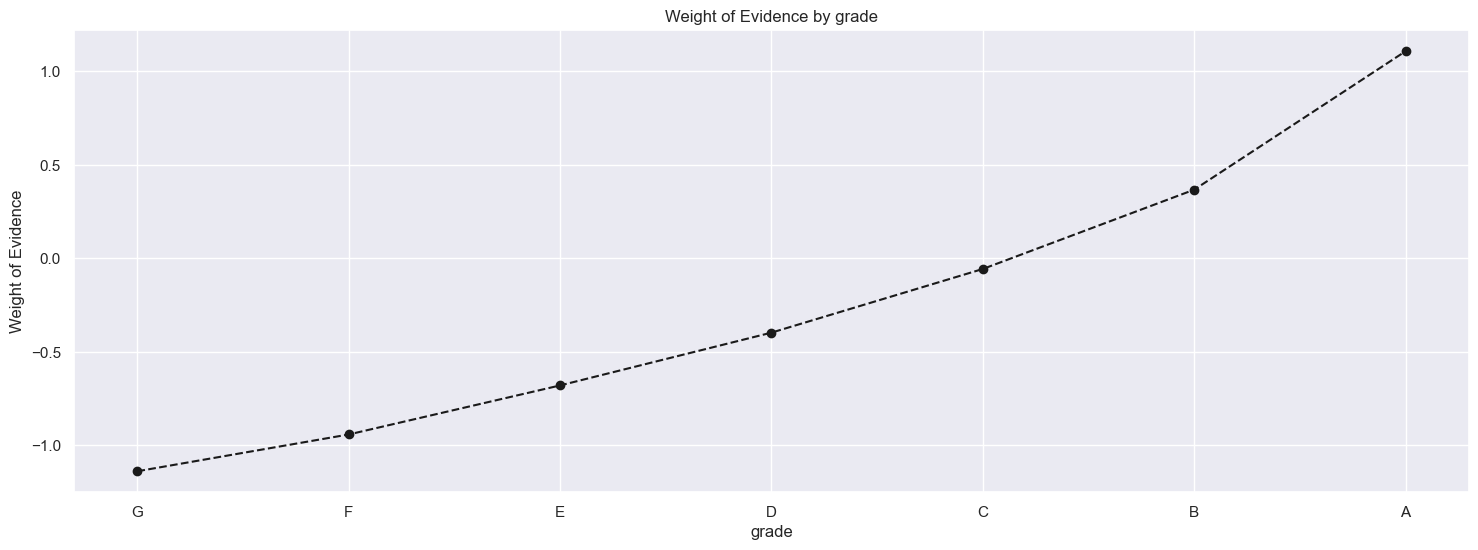

In [64]:
plot_by_woe(df_temp)

Preprocessing Discrete Variables: Creating Dummy Variables, Part 1

In [65]:
df_temp = woe_discrete(df_inputs_prepr, 'home_ownership', df_targets_prepr)
# We calculate weight of evidence.
df_temp

,home_ownership,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,OTHER,147,0.761905,0.000394,112.0,35.0,0.000337,0.000858,-0.934704,NaN,NaN,inf
1,RENT,150791,0.873686,0.404235,131744.0,19047.0,0.396516,0.467136,-0.163904,0.111781,0.770800,inf
2,NONE,33,0.878788,0.000088,29.0,4.0,0.000087,0.000098,-0.116854,0.005102,0.047050,inf
3,OWN,33330,0.891449,0.089350,29712.0,3618.0,0.089426,0.088733,0.007775,0.012661,0.124628,inf
4,MORTGAGE,188726,0.904253,0.505930,170656.0,18070.0,0.513631,0.443175,0.147542,0.012804,0.139767,inf
5,ANY,1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,0.095747,inf,inf


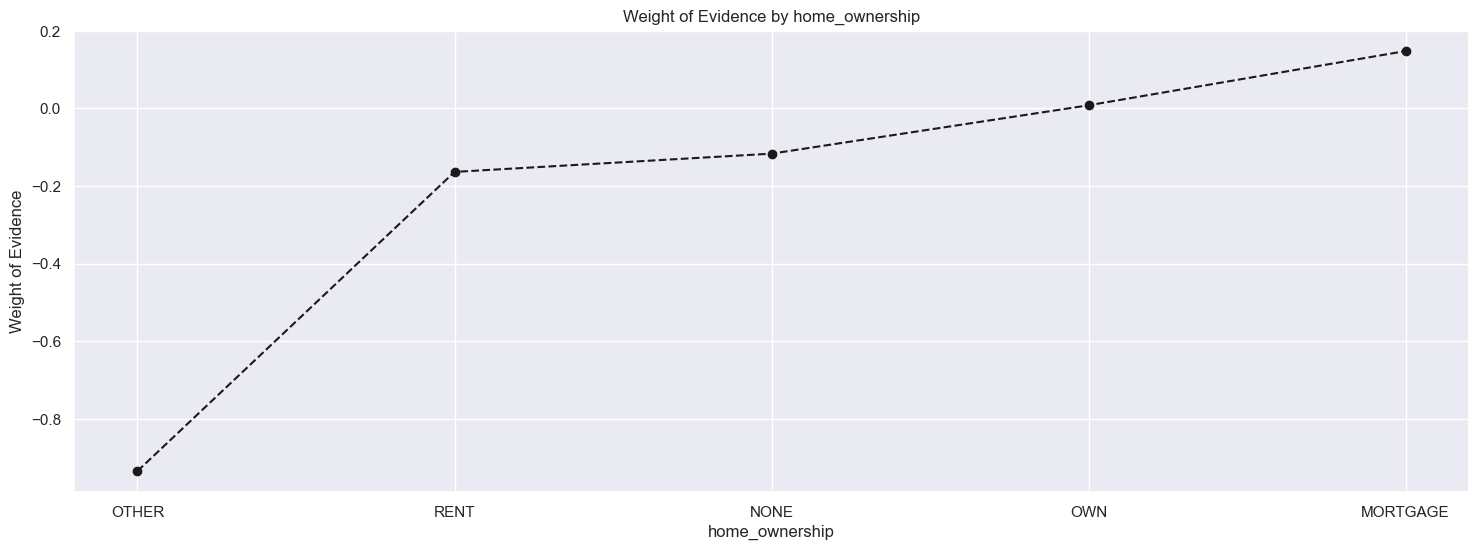

In [66]:
plot_by_woe(df_temp)

In [67]:
df_inputs_prepr['home_ownership:RENT_OTHER_NONE_ANY'] = sum([df_inputs_prepr['home_ownership:RENT'], df_inputs_prepr['home_ownership:OTHER'],
                                                      df_inputs_prepr['home_ownership:NONE'],df_inputs_prepr['home_ownership:ANY']])

In [68]:
df_inputs_prepr_test['home_ownership:RENT_OTHER_NONE_ANY'] = sum([df_inputs_prepr_test['home_ownership:RENT'], df_inputs_prepr_test['home_ownership:OTHER'],
                                                      df_inputs_prepr_test['home_ownership:NONE'],df_inputs_prepr_test['home_ownership:ANY']])

In [69]:
max(df_inputs_prepr['home_ownership:RENT_OTHER_NONE_ANY'].values)

np.int64(1)

Preprocessing Discrete Variables: Creating Dummy Variables, Part 2

In [70]:
df_inputs_prepr['addr_state'].unique()

<StringArray>
['IN', 'CA', 'IL', 'AZ', 'MA', 'MI', 'NY', 'TX', 'SC', 'FL', 'VA', 'NV', 'NC',
 'DE', 'GA', 'MD', 'MN', 'CO', 'PA', 'MS', 'LA', 'NJ', 'CT', 'WV', 'OR', 'WI',
 'AK', 'NH', 'MO', 'UT', 'WA', 'OH', 'TN', 'MT', 'HI', 'OK', 'AR', 'AL', 'VT',
 'KS', 'RI', 'NM', 'SD', 'KY', 'WY', 'DC', 'ID', 'IA', 'NE', 'ME']
Length: 50, dtype: str

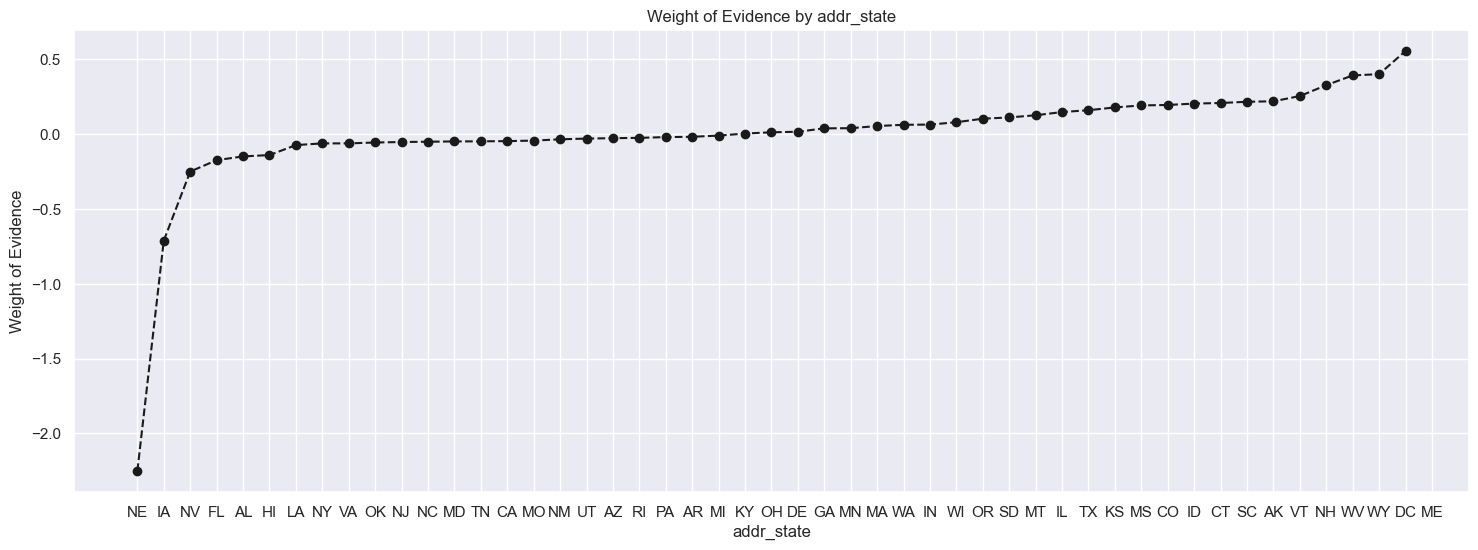

In [71]:
df_temp = woe_discrete(df_inputs_prepr, 'addr_state', df_targets_prepr)
# We calculate weight of evidence.
plot_by_woe(df_temp)
# We plot the weight

In [72]:
if 'addr_state:ND' in df_inputs_prepr.columns.values:
    pass
else:
    df_inputs_prepr['addr_state:ND'] = 0


In [73]:
if 'addr_state:ND' in df_inputs_prepr_test.columns.values:
    pass
else:
    df_inputs_prepr_test['addr_state:ND'] = 0


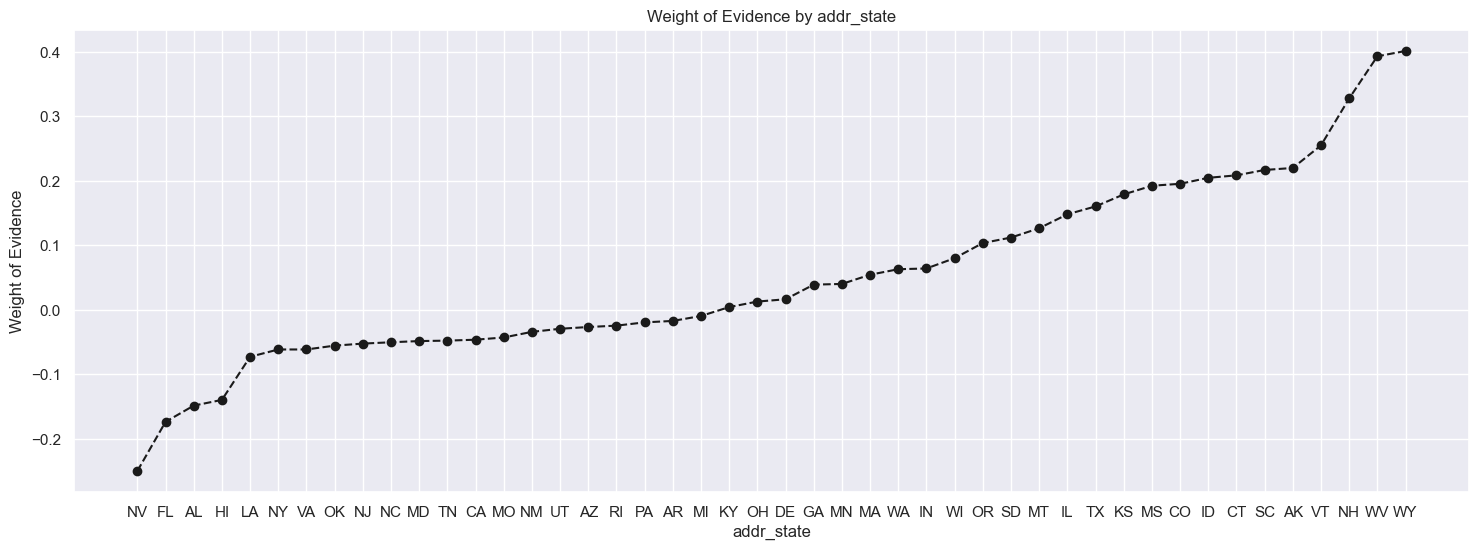

In [74]:
plot_by_woe(df_temp.iloc[2: -2, : ])

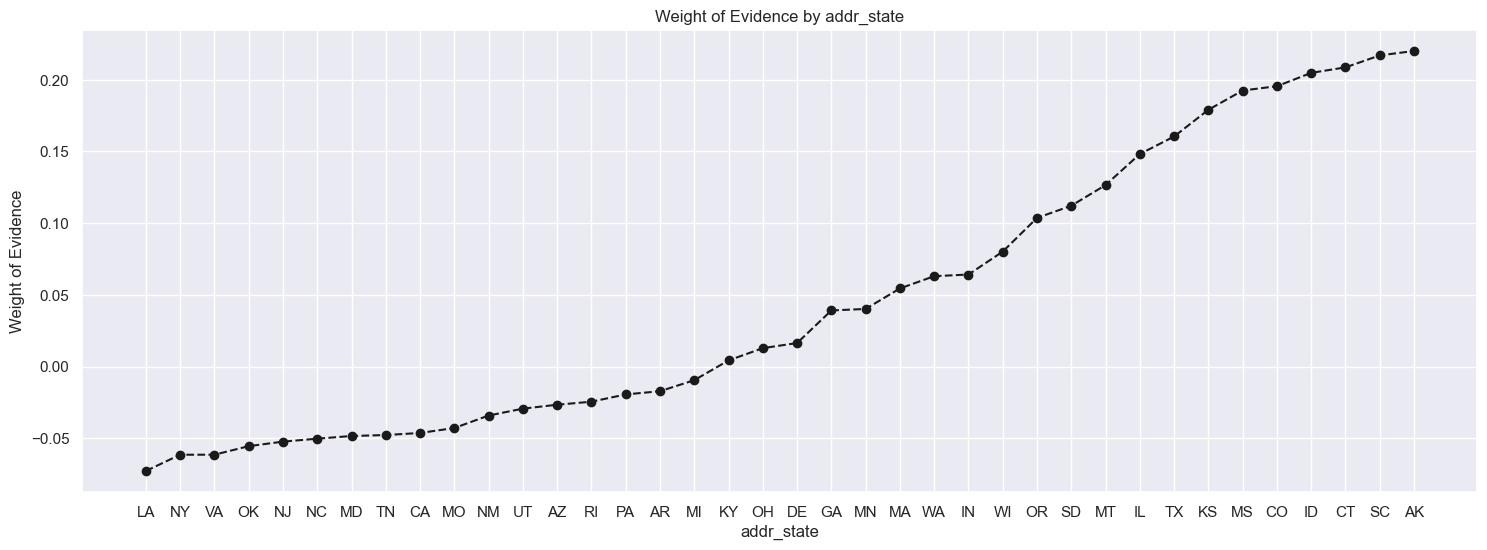

In [75]:
plot_by_woe(df_temp.iloc[6: -6, : ])

In [76]:
df_inputs_prepr['addr_state:ND_NE_IA_NV_FL_HI_AL'] = sum([df_inputs_prepr['addr_state:ND'], df_inputs_prepr['addr_state:NE'],
                                              df_inputs_prepr['addr_state:IA'], df_inputs_prepr['addr_state:NV'],
                                              df_inputs_prepr['addr_state:FL'], df_inputs_prepr['addr_state:HI'],
                                                          df_inputs_prepr['addr_state:AL']])

df_inputs_prepr['addr_state:NM_VA'] = sum([df_inputs_prepr['addr_state:NM'], df_inputs_prepr['addr_state:VA']])

df_inputs_prepr['addr_state:OK_TN_MO_LA_MD_NC'] = sum([df_inputs_prepr['addr_state:OK'], df_inputs_prepr['addr_state:TN'],
                                              df_inputs_prepr['addr_state:MO'], df_inputs_prepr['addr_state:LA'],
                                              df_inputs_prepr['addr_state:MD'], df_inputs_prepr['addr_state:NC']])

df_inputs_prepr['addr_state:UT_KY_AZ_NJ'] = sum([df_inputs_prepr['addr_state:UT'], df_inputs_prepr['addr_state:KY'],
                                              df_inputs_prepr['addr_state:AZ'], df_inputs_prepr['addr_state:NJ']])

df_inputs_prepr['addr_state:AR_MI_PA_OH_MN'] = sum([df_inputs_prepr['addr_state:AR'], df_inputs_prepr['addr_state:MI'],
                                              df_inputs_prepr['addr_state:PA'], df_inputs_prepr['addr_state:OH'],
                                              df_inputs_prepr['addr_state:MN']])

df_inputs_prepr['addr_state:RI_MA_DE_SD_IN'] = sum([df_inputs_prepr['addr_state:RI'], df_inputs_prepr['addr_state:MA'],
                                              df_inputs_prepr['addr_state:DE'], df_inputs_prepr['addr_state:SD'],
                                              df_inputs_prepr['addr_state:IN']])

df_inputs_prepr['addr_state:GA_WA_OR'] = sum([df_inputs_prepr['addr_state:GA'], df_inputs_prepr['addr_state:WA'],
                                              df_inputs_prepr['addr_state:OR']])

df_inputs_prepr['addr_state:WI_MT'] = sum([df_inputs_prepr['addr_state:WI'], df_inputs_prepr['addr_state:MT']])

df_inputs_prepr['addr_state:IL_CT'] = sum([df_inputs_prepr['addr_state:IL'], df_inputs_prepr['addr_state:CT']])

df_inputs_prepr['addr_state:KS_SC_CO_VT_AK_MS'] = sum([df_inputs_prepr['addr_state:KS'], df_inputs_prepr['addr_state:SC'],
                                              df_inputs_prepr['addr_state:CO'], df_inputs_prepr['addr_state:VT'],
                                              df_inputs_prepr['addr_state:AK'], df_inputs_prepr['addr_state:MS']])

df_inputs_prepr['addr_state:WV_NH_WY_DC_ME_ID'] = sum([df_inputs_prepr['addr_state:WV'], df_inputs_prepr['addr_state:NH'],
                                              df_inputs_prepr['addr_state:WY'], df_inputs_prepr['addr_state:DC'],
                                              df_inputs_prepr['addr_state:ME'], df_inputs_prepr['addr_state:ID']])

In [77]:
df_inputs_prepr_test['addr_state:ND_NE_IA_NV_FL_HI_AL'] = sum([df_inputs_prepr_test['addr_state:ND'], df_inputs_prepr_test['addr_state:NE'],
                                              df_inputs_prepr_test['addr_state:IA'], df_inputs_prepr_test['addr_state:NV'],
                                              df_inputs_prepr_test['addr_state:FL'], df_inputs_prepr_test['addr_state:HI'],
                                                          df_inputs_prepr_test['addr_state:AL']])

df_inputs_prepr_test['addr_state:NM_VA'] = sum([df_inputs_prepr_test['addr_state:NM'], df_inputs_prepr_test['addr_state:VA']])

df_inputs_prepr_test['addr_state:OK_TN_MO_LA_MD_NC'] = sum([df_inputs_prepr_test['addr_state:OK'], df_inputs_prepr_test['addr_state:TN'],
                                              df_inputs_prepr_test['addr_state:MO'], df_inputs_prepr_test['addr_state:LA'],
                                              df_inputs_prepr_test['addr_state:MD'], df_inputs_prepr_test['addr_state:NC']])

df_inputs_prepr_test['addr_state:UT_KY_AZ_NJ'] = sum([df_inputs_prepr_test['addr_state:UT'], df_inputs_prepr_test['addr_state:KY'],
                                              df_inputs_prepr_test['addr_state:AZ'], df_inputs_prepr_test['addr_state:NJ']])

df_inputs_prepr_test['addr_state:AR_MI_PA_OH_MN'] = sum([df_inputs_prepr_test['addr_state:AR'], df_inputs_prepr_test['addr_state:MI'],
                                              df_inputs_prepr_test['addr_state:PA'], df_inputs_prepr_test['addr_state:OH'],
                                              df_inputs_prepr_test['addr_state:MN']])

df_inputs_prepr_test['addr_state:RI_MA_DE_SD_IN'] = sum([df_inputs_prepr_test['addr_state:RI'], df_inputs_prepr_test['addr_state:MA'],
                                              df_inputs_prepr_test['addr_state:DE'], df_inputs_prepr_test['addr_state:SD'],
                                              df_inputs_prepr_test['addr_state:IN']])

df_inputs_prepr_test['addr_state:GA_WA_OR'] = sum([df_inputs_prepr_test['addr_state:GA'], df_inputs_prepr_test['addr_state:WA'],
                                              df_inputs_prepr_test['addr_state:OR']])

df_inputs_prepr_test['addr_state:WI_MT'] = sum([df_inputs_prepr_test['addr_state:WI'], df_inputs_prepr_test['addr_state:MT']])

df_inputs_prepr_test['addr_state:IL_CT'] = sum([df_inputs_prepr_test['addr_state:IL'], df_inputs_prepr_test['addr_state:CT']])

df_inputs_prepr_test['addr_state:KS_SC_CO_VT_AK_MS'] = sum([df_inputs_prepr_test['addr_state:KS'], df_inputs_prepr_test['addr_state:SC'],
                                              df_inputs_prepr_test['addr_state:CO'], df_inputs_prepr_test['addr_state:VT'],
                                              df_inputs_prepr_test['addr_state:AK'], df_inputs_prepr_test['addr_state:MS']])

df_inputs_prepr_test['addr_state:WV_NH_WY_DC_ME_ID'] = sum([df_inputs_prepr_test['addr_state:WV'], df_inputs_prepr_test['addr_state:NH'],
                                              df_inputs_prepr_test['addr_state:WY'], df_inputs_prepr_test['addr_state:DC'],
                                              df_inputs_prepr_test['addr_state:ME'], df_inputs_prepr_test['addr_state:ID']])

verification status

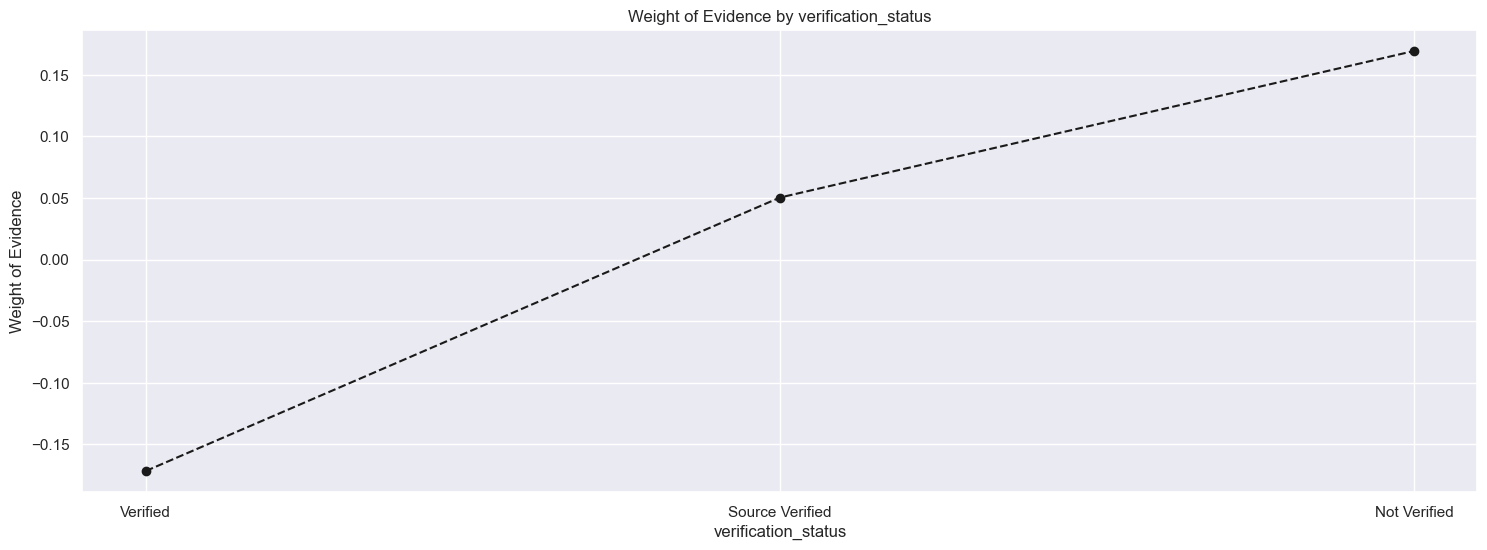

In [78]:
df_temp = woe_discrete(df_inputs_prepr, 'verification_status', df_targets_prepr)
plot_by_woe(df_temp)

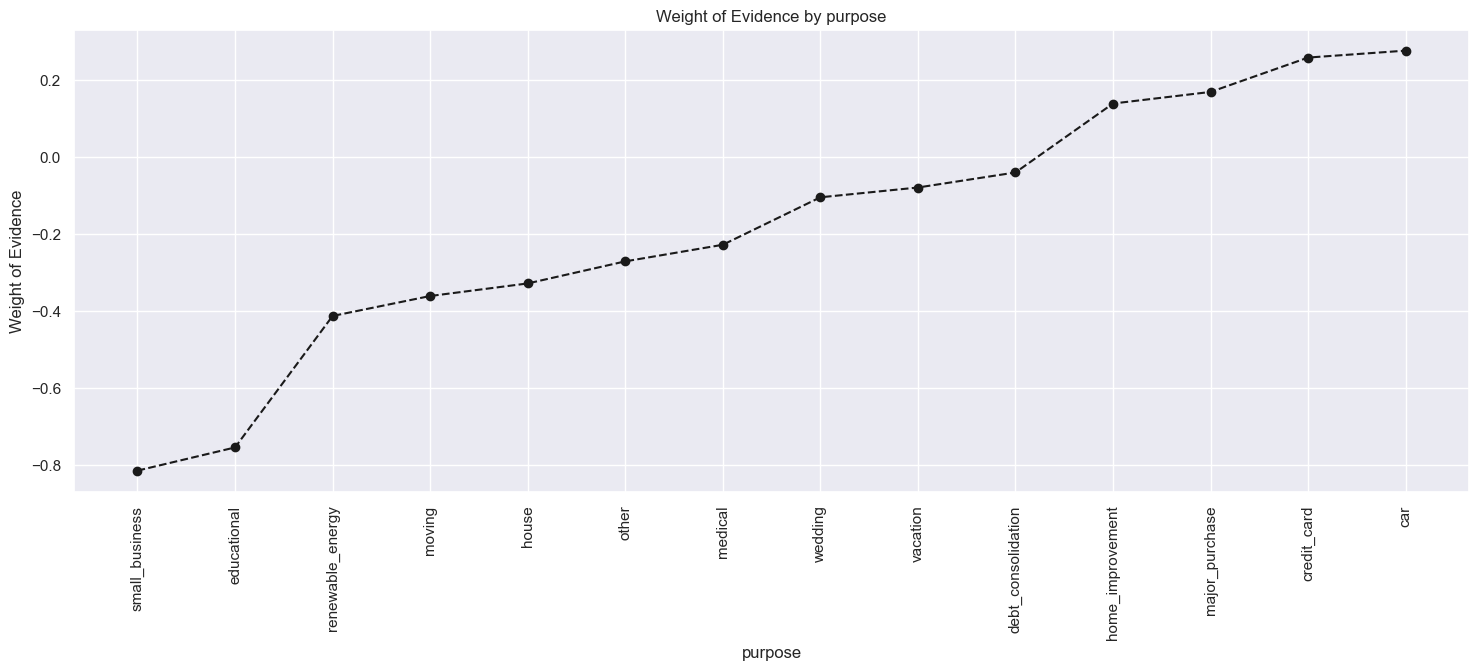

In [79]:
df_temp = woe_discrete(df_inputs_prepr, 'purpose', df_targets_prepr)
plot_by_woe(df_temp, 90)

In [80]:
df_inputs_prepr['purpose:educ__sm_b__wedd__ren_en__mov__house'] = sum([df_inputs_prepr['purpose:educational'], df_inputs_prepr['purpose:small_business'],
                                                                 df_inputs_prepr['purpose:wedding'], df_inputs_prepr['purpose:renewable_energy'],
                                                                 df_inputs_prepr['purpose:moving'], df_inputs_prepr['purpose:house']])
df_inputs_prepr['purpose:oth__med__vacation'] = sum([df_inputs_prepr['purpose:other'], df_inputs_prepr['purpose:medical'],
                                             df_inputs_prepr['purpose:vacation']])
df_inputs_prepr['purpose:major_purch__car__home_impr'] = sum([df_inputs_prepr['purpose:major_purchase'], df_inputs_prepr['purpose:car'],
                                                        df_inputs_prepr['purpose:home_improvement']])

In [81]:
df_inputs_prepr_test['purpose:educ__sm_b__wedd__ren_en__mov__house'] = sum([df_inputs_prepr_test['purpose:educational'], df_inputs_prepr_test['purpose:small_business'],
                                                                 df_inputs_prepr_test['purpose:wedding'], df_inputs_prepr_test['purpose:renewable_energy'],
                                                                 df_inputs_prepr_test['purpose:moving'], df_inputs_prepr_test['purpose:house']])
df_inputs_prepr_test['purpose:oth__med__vacation'] = sum([df_inputs_prepr_test['purpose:other'], df_inputs_prepr_test['purpose:medical'],
                                             df_inputs_prepr_test['purpose:vacation']])
df_inputs_prepr_test['purpose:major_purch__car__home_impr'] = sum([df_inputs_prepr_test['purpose:major_purchase'], df_inputs_prepr_test['purpose:car'],
                                                        df_inputs_prepr_test['purpose:home_improvement']])

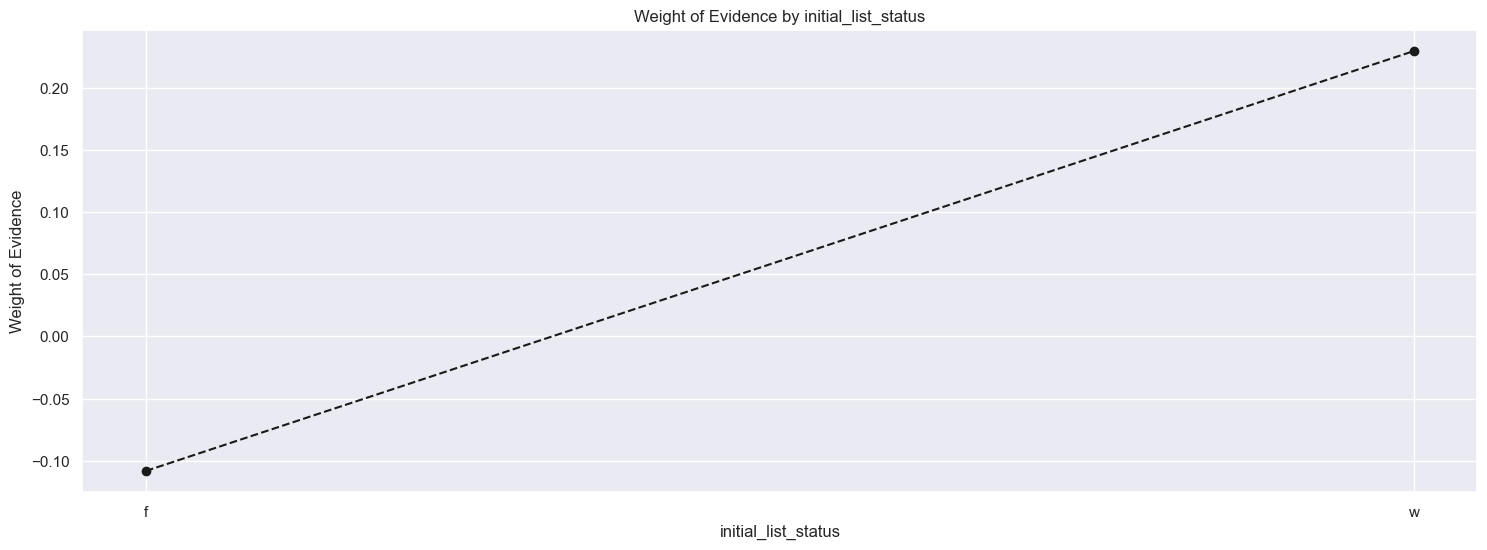

In [82]:
# 'initial_list_status'
df_temp = woe_discrete(df_inputs_prepr, 'initial_list_status', df_targets_prepr)
plot_by_woe(df_temp)

In [83]:
def woe_ordered_continuous(df, discrete_variabe_name, good_bad_variable_df):
    df = pd.concat([df[discrete_variabe_name], good_bad_variable_df], axis = 1)
    df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
                    df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_good']
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['prop_good'] * df['n_obs']
    df['n_bad'] = (1 - df['prop_good']) * df['n_obs']
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    #df = df.sort_values(['WoE'])
    #df = df.reset_index(drop = True)
    df['diff_prop_good'] = df['prop_good'].diff().abs()
    df['diff_WoE'] = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    return df

Preprocessing Continuous Variables

In [84]:
df_inputs_prepr['term_int'].unique()
df_temp = woe_ordered_continuous(df_inputs_prepr, 'term_int', df_targets_prepr)

In [85]:
df_temp

,term_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,36,270247,0.902874,0.724468,243999.0,26248.0,0.734375,0.643744,0.131719,NaN,NaN,0.038544
1,60,102781,0.858670,0.275532,88255.0,14526.0,0.265625,0.356256,-0.293565,0.044204,0.425284,0.038544


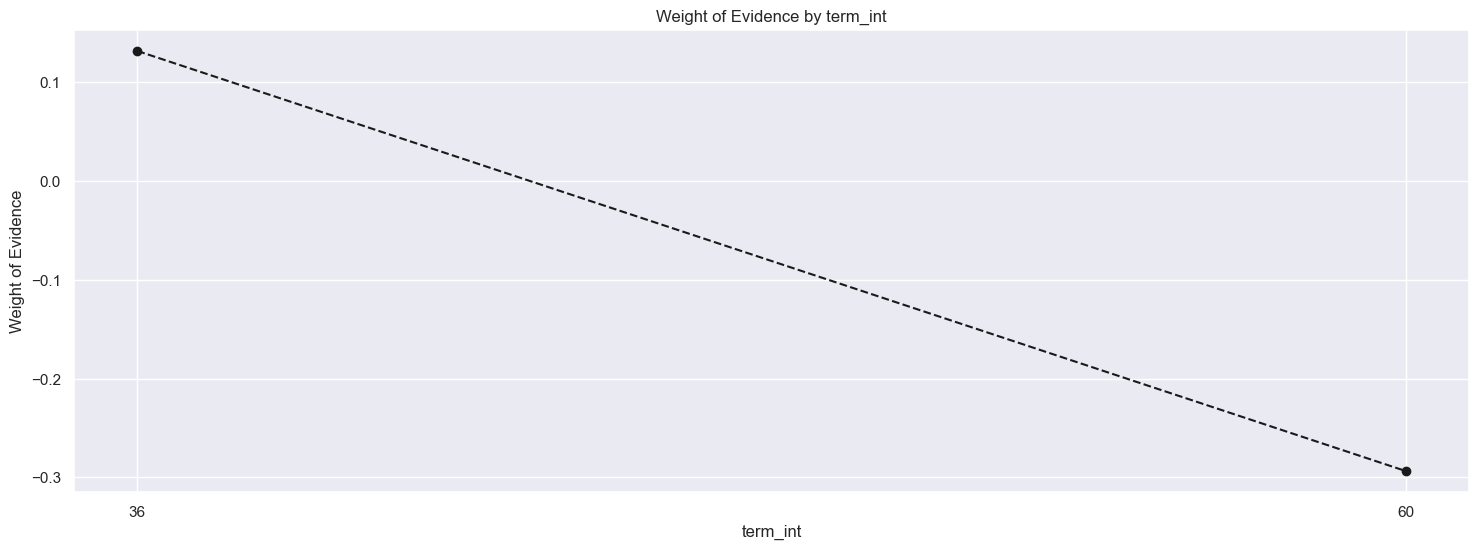

In [86]:
plot_by_woe(df_temp)

In [87]:
df_inputs_prepr['term:36'] = np.where((df_inputs_prepr['term_int'] == 36), 1, 0)
df_inputs_prepr['term:60'] = np.where((df_inputs_prepr['term_int'] == 60), 1, 0)

In [88]:
df_inputs_prepr_test['term:36'] = np.where((df_inputs_prepr_test['term_int'] == 36), 1, 0)
df_inputs_prepr_test['term:60'] = np.where((df_inputs_prepr_test['term_int'] == 60), 1, 0)

In [89]:
df_inputs_prepr['emp_length_int'].unique()

array([ 1.,  9., 10.,  7.,  3.,  0.,  8.,  2., nan,  5.,  4.,  6.])

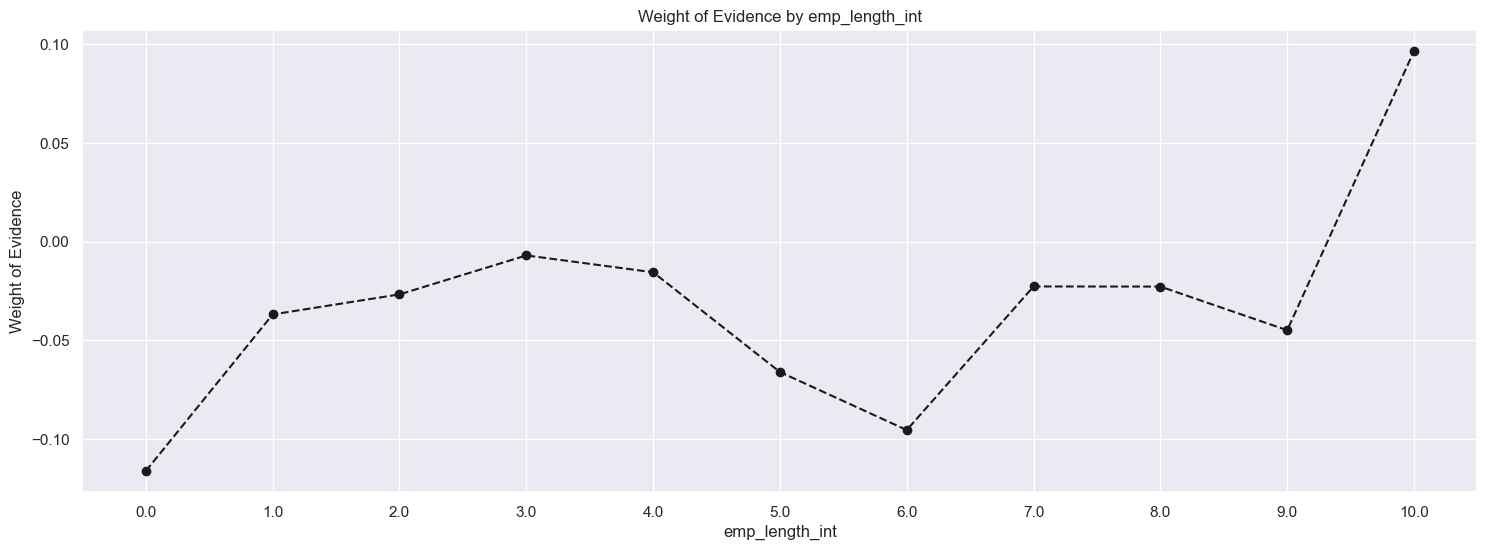

In [90]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'emp_length_int', df_targets_prepr)
plot_by_woe(df_temp)

In [91]:
df_inputs_prepr['emp_length:0'] = np.where(df_inputs_prepr['emp_length_int'].isin([0]), 1, 0)
df_inputs_prepr['emp_length:1'] = np.where(df_inputs_prepr['emp_length_int'].isin([1]), 1, 0)
df_inputs_prepr['emp_length:2-4'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(2, 5)), 1, 0)
df_inputs_prepr['emp_length:5-6'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(5, 7)), 1, 0)
df_inputs_prepr['emp_length:7-9'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(7, 10)), 1, 0)
df_inputs_prepr['emp_length:10'] = np.where(df_inputs_prepr['emp_length_int'].isin([10]), 1, 0)

In [92]:
df_inputs_prepr_test['emp_length:0'] = np.where(df_inputs_prepr_test['emp_length_int'].isin([0]), 1, 0)
df_inputs_prepr_test['emp_length:1'] = np.where(df_inputs_prepr_test['emp_length_int'].isin([1]), 1, 0)
df_inputs_prepr_test['emp_length:2-4'] = np.where(df_inputs_prepr_test['emp_length_int'].isin(range(2, 5)), 1, 0)
df_inputs_prepr_test['emp_length:5-6'] = np.where(df_inputs_prepr_test['emp_length_int'].isin(range(5, 7)), 1, 0)
df_inputs_prepr_test['emp_length:7-9'] = np.where(df_inputs_prepr_test['emp_length_int'].isin(range(7, 10)), 1, 0)
df_inputs_prepr_test['emp_length:10'] = np.where(df_inputs_prepr_test['emp_length_int'].isin([10]), 1, 0)

In [93]:
df_inputs_prepr['mths_since_issue_d'].unique()

array([158., 139., 141., 152., 149., 153., 148., 151., 138., 137., 146.,
       164., 144., 206., 160., 143., 167., 156., 150., 163., 155., 165.,
       136., 159., 140., 205., 157., 145., 147., 161., 154., 142., 183.,
       173., 169., 204., 180., 168., 187., 177., 185., 198., 166., 171.,
       162., 172., 207., 213., 182., 193., 179., 178., 184., 176., 170.,
       194., 186., 188., 209., 199., 174., 175., 189., 200., 192., 181.,
       190., 197., 196., 216., 219., 217., 218., 203., 201., 195., 191.,
       221., 202., 210., 220., 212., 214., 208., 224., 223., 215., 225.,
       222., 211., 226.])

In [94]:
min(df_inputs_prepr['mths_since_issue_d'].unique())
max(df_inputs_prepr['mths_since_issue_d'].unique())

np.float64(226.0)

In [95]:
df_inputs_prepr['mths_since_issue_d_factor'] = pd.cut(df_inputs_prepr['mths_since_issue_d'], 50)

In [96]:
bin_edges = df_inputs_prepr['mths_since_issue_d_factor'].cat.categories
df_inputs_prepr_test['mths_since_issue_d_factor'] = pd.cut(df_inputs_prepr_test['mths_since_issue_d'], bins=bin_edges)

In [97]:
df_inputs_prepr['mths_since_issue_d_factor']

167844     (157.6, 159.4]
304337     (137.8, 139.6]
355929     (139.6, 141.4]
97687      (150.4, 152.2]
62651      (148.6, 150.4]
               ...       
253811    (135.91, 137.8]
430295     (143.2, 145.0]
28255      (188.2, 190.0]
147327     (155.8, 157.6]
156490     (155.8, 157.6]
Name: mths_since_issue_d_factor, Length: 373028, dtype: category
Categories (50, interval[float64, right]): [(135.91, 137.8] < (137.8, 139.6] < (139.6, 141.4] < (141.4, 143.2] ... (218.8, 220.6] < (220.6, 222.4] < (222.4, 224.2] < (224.2, 226.0]]

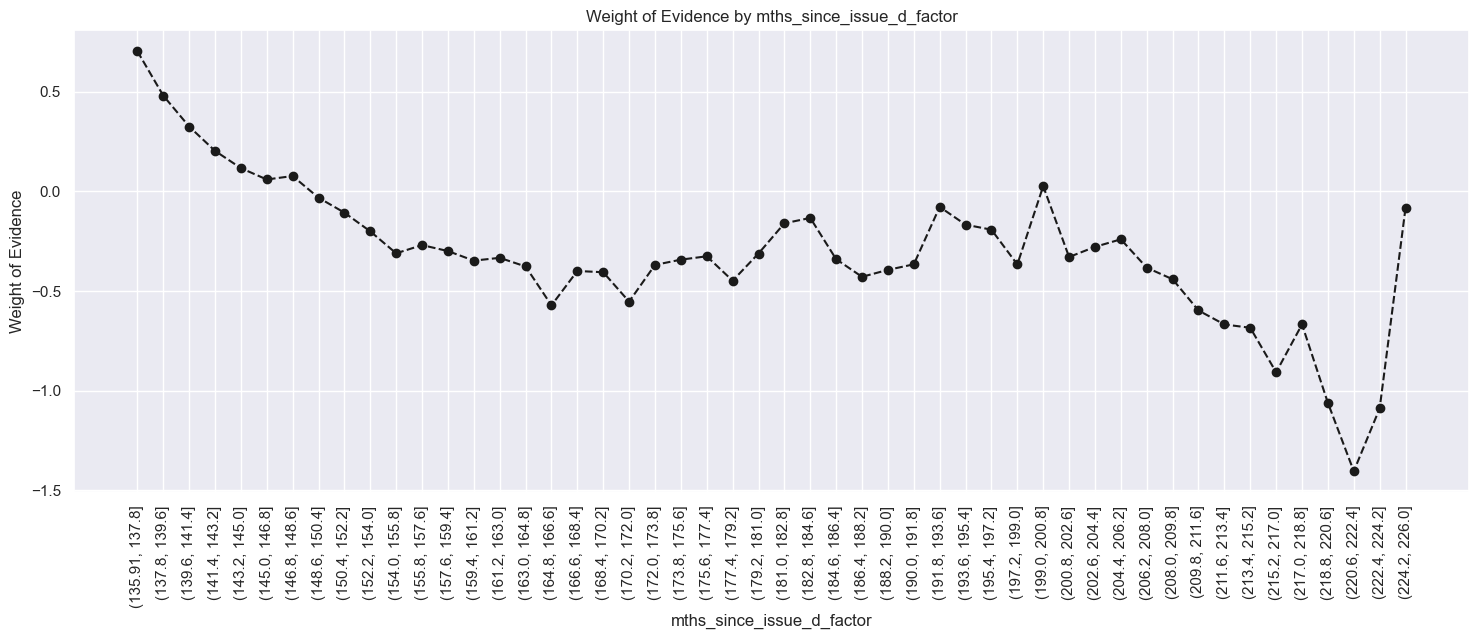

In [98]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'mths_since_issue_d_factor', df_targets_prepr)
plot_by_woe(df_temp,90)

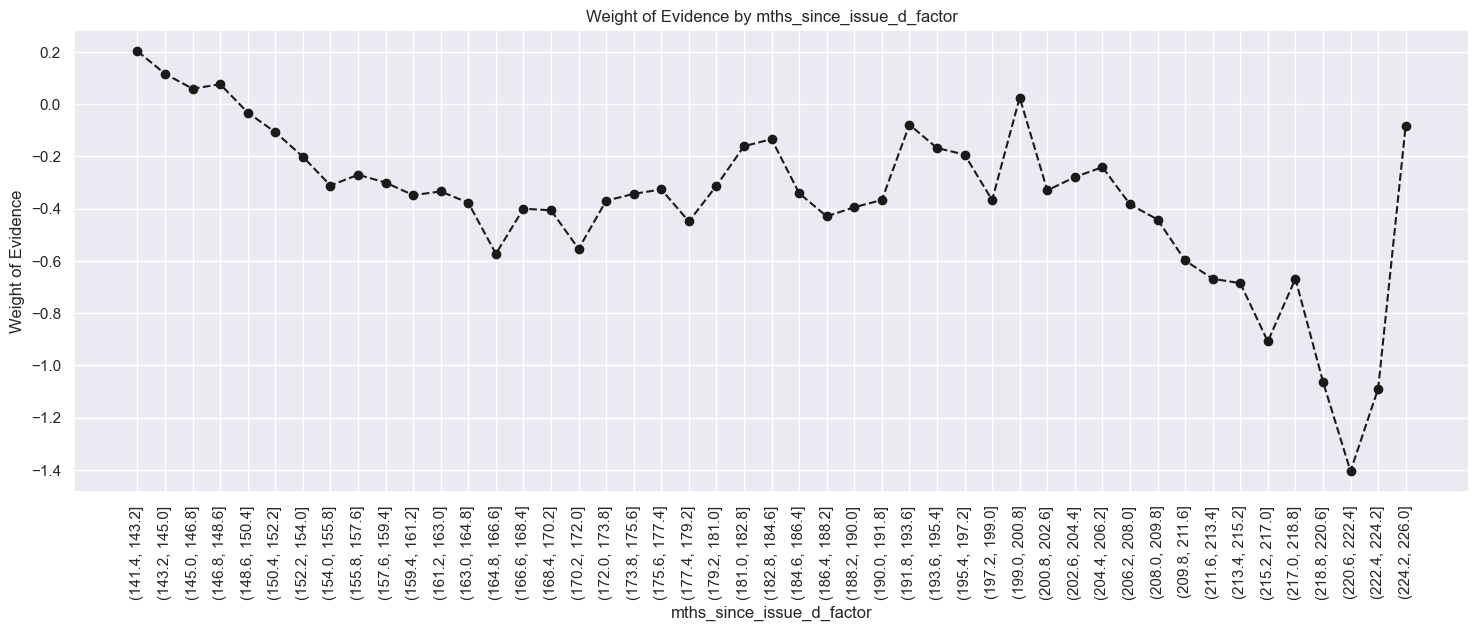

In [99]:
plot_by_woe(df_temp.iloc[3: , : ], 90)

In [100]:
df_inputs_prepr['mths_since_issue_d:<38'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(38)), 1, 0)
df_inputs_prepr['mths_since_issue_d:38-39'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(38, 40)), 1, 0)
df_inputs_prepr['mths_since_issue_d:40-41'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(40, 42)), 1, 0)
df_inputs_prepr['mths_since_issue_d:42-48'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(42, 49)), 1, 0)
df_inputs_prepr['mths_since_issue_d:49-52'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(49, 53)), 1, 0)
df_inputs_prepr['mths_since_issue_d:53-64'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(53, 65)), 1, 0)
df_inputs_prepr['mths_since_issue_d:65-84'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(65, 85)), 1, 0)
df_inputs_prepr['mths_since_issue_d:>84'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(85, int(df_inputs_prepr['mths_since_issue_d'].max()))), 1, 0)

In [101]:
df_inputs_prepr_test['mths_since_issue_d:<38'] = np.where(df_inputs_prepr_test['mths_since_issue_d'].isin(range(38)), 1, 0)
df_inputs_prepr_test['mths_since_issue_d:38-39'] = np.where(df_inputs_prepr_test['mths_since_issue_d'].isin(range(38, 40)), 1, 0)
df_inputs_prepr_test['mths_since_issue_d:40-41'] = np.where(df_inputs_prepr_test['mths_since_issue_d'].isin(range(40, 42)), 1, 0)
df_inputs_prepr_test['mths_since_issue_d:42-48'] = np.where(df_inputs_prepr_test['mths_since_issue_d'].isin(range(42, 49)), 1, 0)
df_inputs_prepr_test['mths_since_issue_d:49-52'] = np.where(df_inputs_prepr_test['mths_since_issue_d'].isin(range(49, 53)), 1, 0)
df_inputs_prepr_test['mths_since_issue_d:53-64'] = np.where(df_inputs_prepr_test['mths_since_issue_d'].isin(range(53, 65)), 1, 0)
df_inputs_prepr_test['mths_since_issue_d:65-84'] = np.where(df_inputs_prepr_test['mths_since_issue_d'].isin(range(65, 85)), 1, 0)
df_inputs_prepr_test['mths_since_issue_d:>84'] = np.where(df_inputs_prepr_test['mths_since_issue_d'].isin(range(85, int(df_inputs_prepr['mths_since_issue_d'].max()))), 1, 0)

In [102]:
df_inputs_prepr['int_rate'].unique()

array([19.05, 10.15, 13.35, 25.8 , 18.55, 11.55, 15.61, 13.67, 14.33,
        7.69, 21.99, 14.64, 11.67, 13.98, 17.27, 14.16, 15.05, 12.85,
       13.68, 18.99, 11.44,  9.71, 14.49, 12.49, 17.57, 12.12, 12.99,
       21.  , 16.29, 18.49,  8.19, 15.31, 16.2 , 16.99, 18.85, 14.09,
       19.72, 11.14, 14.98, 20.2 , 10.99, 13.11, 13.16, 23.76, 15.8 ,
       18.25, 16.59, 19.52, 15.22,  7.9 , 12.35, 11.99, 12.39, 25.89,
       19.36, 20.5 ,  9.91, 16.77,  6.49,  6.62, 17.77, 22.15, 13.66,
       18.24, 13.99, 11.58, 24.5 , 23.28,  6.03, 14.99, 15.37, 18.92,
       10.37, 21.97, 20.8 , 13.61, 17.49,  5.42,  7.62,  8.94, 16.49,
       15.81, 13.65, 19.99, 14.31, 12.69,  8.39, 11.71, 22.4 , 10.16,
        8.9 , 13.06, 18.54, 11.89, 10.65, 13.53, 13.55, 21.98,  9.17,
       10.49,  9.67, 11.36, 10.64, 17.76, 25.57,  9.25,  8.6 , 16.89,
       22.7 , 17.56, 15.88, 23.5 , 12.21, 18.75, 15.59, 22.95, 14.3 ,
       14.65, 24.08, 22.74, 20.31, 21.7 , 19.2 , 19.22, 13.49, 23.4 ,
       23.43, 15.99,

In [103]:
df_inputs_prepr['int_rate_factor'] = pd.cut(df_inputs_prepr['int_rate'], 50)

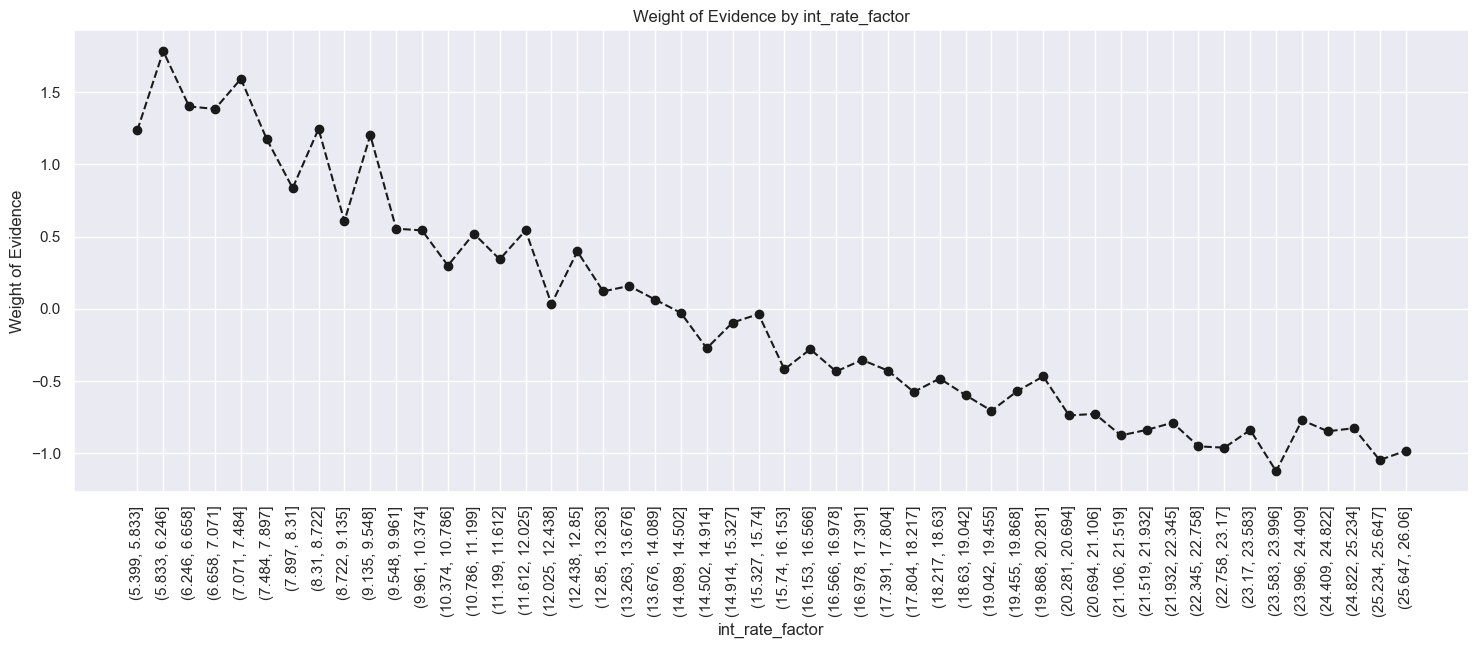

In [104]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'int_rate_factor', df_targets_prepr)
plot_by_woe(df_temp, 90)

In [105]:
bin_edges = df_inputs_prepr['int_rate_factor'].cat.categories
df_inputs_prepr_test['int_rate_factor'] = pd.cut(df_inputs_prepr_test['int_rate'], bins=bin_edges)

In [106]:
df_inputs_prepr['int_rate:<9.548'] = np.where((df_inputs_prepr['int_rate'] <= 9.548), 1, 0)
df_inputs_prepr['int_rate:9.548-12.025'] = np.where((df_inputs_prepr['int_rate'] > 9.548) & (df_inputs_prepr['int_rate'] <= 12.025), 1, 0)
df_inputs_prepr['int_rate:12.025-15.74'] = np.where((df_inputs_prepr['int_rate'] > 12.025) & (df_inputs_prepr['int_rate'] <= 15.74), 1, 0)
df_inputs_prepr['int_rate:15.74-20.281'] = np.where((df_inputs_prepr['int_rate'] > 15.74) & (df_inputs_prepr['int_rate'] <= 20.281), 1, 0)
df_inputs_prepr['int_rate:>20.281'] = np.where((df_inputs_prepr['int_rate'] > 20.281), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1665787287.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['int_rate:9.548-12.025'] = np.where((df_inputs_prepr['int_rate'] > 9.548) & (df_inputs_prepr['int_rate'] <= 12.025), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1665787287.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['int_rate:12.025-15.74'] = np.where((df_inputs_prepr['int_rate'] > 12.025) & (df_inputs_prepr['int_rate'] <= 15.74), 1, 0)
C:\Users\kshit\AppData\Local\T

In [107]:
df_inputs_prepr_test['int_rate:<9.548'] = np.where((df_inputs_prepr_test['int_rate'] <= 9.548), 1, 0)
df_inputs_prepr_test['int_rate:9.548-12.025'] = np.where((df_inputs_prepr_test['int_rate'] > 9.548) & (df_inputs_prepr_test['int_rate'] <= 12.025), 1, 0)
df_inputs_prepr_test['int_rate:12.025-15.74'] = np.where((df_inputs_prepr_test['int_rate'] > 12.025) & (df_inputs_prepr_test['int_rate'] <= 15.74), 1, 0)
df_inputs_prepr_test['int_rate:15.74-20.281'] = np.where((df_inputs_prepr_test['int_rate'] > 15.74) & (df_inputs_prepr_test['int_rate'] <= 20.281), 1, 0)
df_inputs_prepr_test['int_rate:>20.281'] = np.where((df_inputs_prepr_test['int_rate'] > 20.281), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2834292068.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['int_rate:9.548-12.025'] = np.where((df_inputs_prepr_test['int_rate'] > 9.548) & (df_inputs_prepr_test['int_rate'] <= 12.025), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2834292068.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['int_rate:12.025-15.74'] = np.where((df_inputs_prepr_test['int_rate'] > 12.025) & (df_inputs_prepr_test['int_rate'] <= 15.74), 1, 0)


C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\880692791.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['funded_amnt_factor'] = pd.cut(df_inputs_prepr['funded_amnt'], 50)


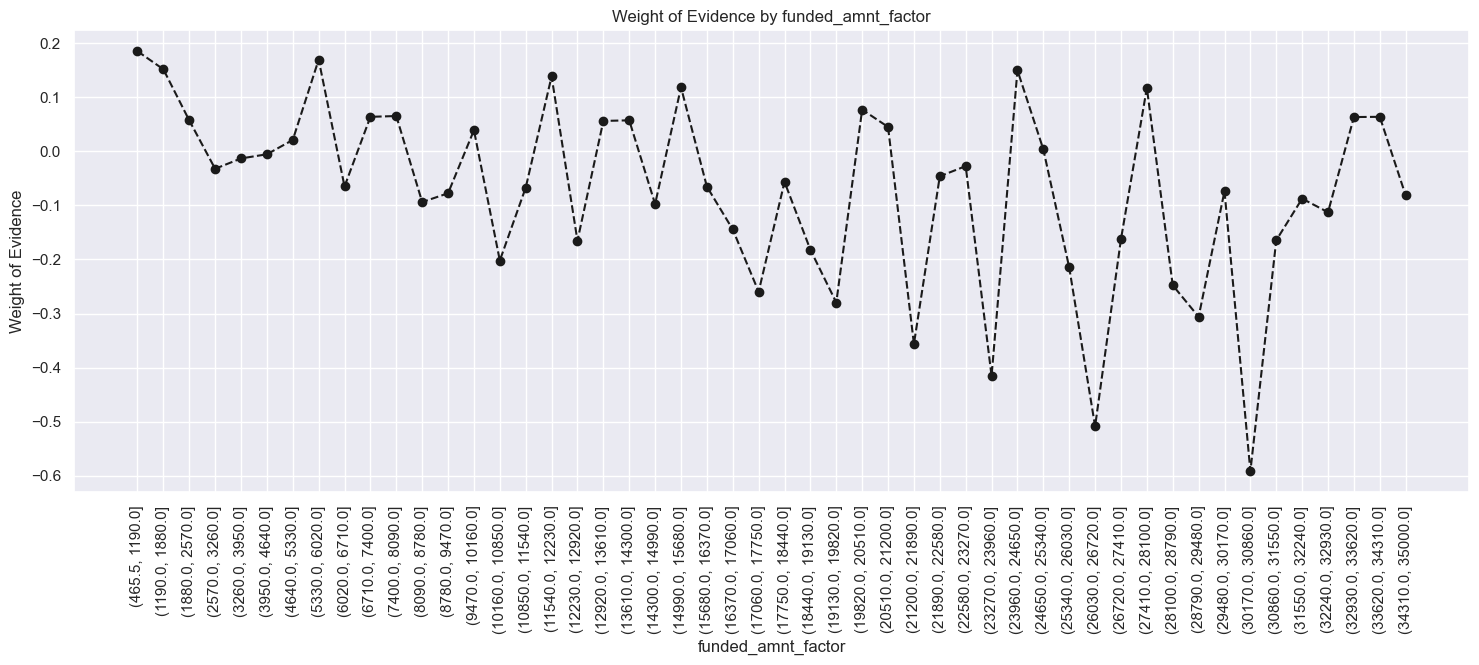

In [108]:
df_inputs_prepr['funded_amnt_factor'] = pd.cut(df_inputs_prepr['funded_amnt'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr, 'funded_amnt_factor', df_targets_prepr)
plot_by_woe(df_temp, 90)

In [109]:
bin_edges = df_inputs_prepr['funded_amnt_factor'].cat.categories
df_inputs_prepr_test['funded_amnt_factor'] = pd.cut(df_inputs_prepr_test['funded_amnt'], bins=bin_edges)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2515888048.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['funded_amnt_factor'] = pd.cut(df_inputs_prepr_test['funded_amnt'], bins=bin_edges)


C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1171188135.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_earliest_cr_line_factor'] = pd.cut(df_inputs_prepr['mths_since_earliest_cr_line'], 50)


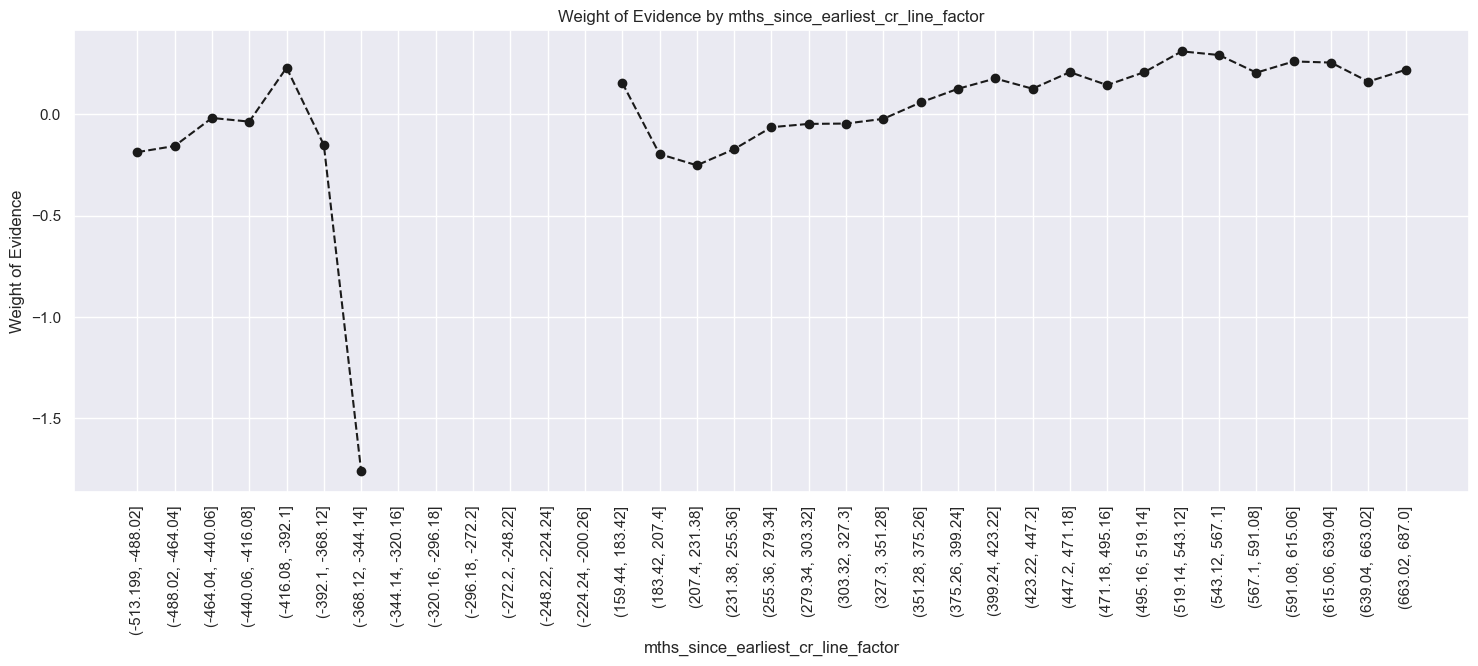

In [110]:
df_inputs_prepr['mths_since_earliest_cr_line_factor'] = pd.cut(df_inputs_prepr['mths_since_earliest_cr_line'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'mths_since_earliest_cr_line_factor', df_targets_prepr)
plot_by_woe(df_temp, 90)

In [111]:
bin_edges = df_inputs_prepr['mths_since_earliest_cr_line_factor'].cat.categories
df_inputs_prepr_test['mths_since_earliest_cr_line_factor'] = pd.cut(df_inputs_prepr_test['mths_since_earliest_cr_line'], bins=bin_edges)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\4159092678.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['mths_since_earliest_cr_line_factor'] = pd.cut(df_inputs_prepr_test['mths_since_earliest_cr_line'], bins=bin_edges)


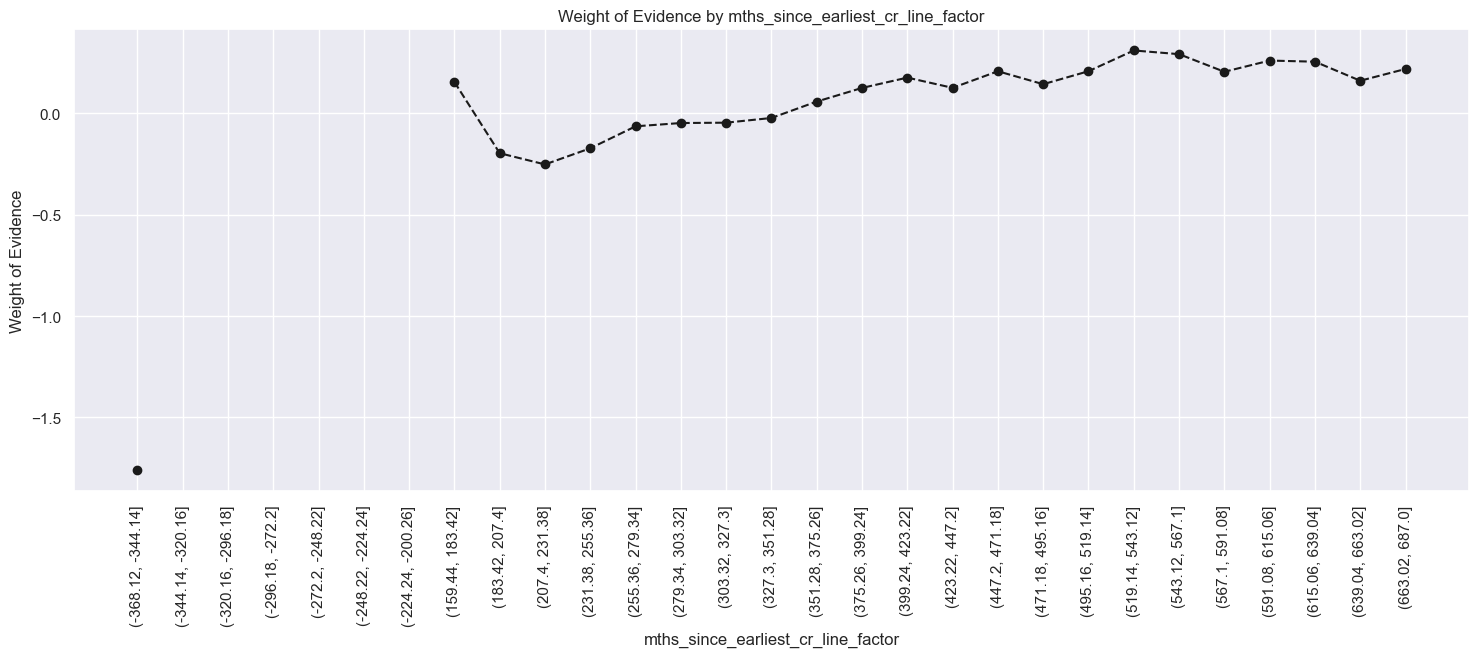

In [112]:
plot_by_woe(df_temp.iloc[6: , : ], 90)

In [113]:
df_inputs_prepr['mths_since_earliest_cr_line:<140'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(140)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:141-164'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(140, 165)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:165-247'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(165, 248)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:248-270'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(248, 271)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:271-352'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(271, 353)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:>352'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(353, int(df_inputs_prepr['mths_since_earliest_cr_line'].max()))), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1221893734.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_earliest_cr_line:<140'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(140)), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1221893734.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_earliest_cr_line:141-164'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(140, 165)), 1, 0)


C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1221893734.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_earliest_cr_line:165-247'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(165, 248)), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1221893734.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_earliest_cr_line:248-270'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(248, 271)), 1, 0)


C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1221893734.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_earliest_cr_line:271-352'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(271, 353)), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1221893734.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_earliest_cr_line:>352'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(353, int(df_inputs_prepr['mths_since_earliest

In [114]:
df_inputs_prepr_test['mths_since_earliest_cr_line:<140'] = np.where(df_inputs_prepr_test['mths_since_earliest_cr_line'].isin(range(140)), 1, 0)
df_inputs_prepr_test['mths_since_earliest_cr_line:141-164'] = np.where(df_inputs_prepr_test['mths_since_earliest_cr_line'].isin(range(140, 165)), 1, 0)
df_inputs_prepr_test['mths_since_earliest_cr_line:165-247'] = np.where(df_inputs_prepr_test['mths_since_earliest_cr_line'].isin(range(165, 248)), 1, 0)
df_inputs_prepr_test['mths_since_earliest_cr_line:248-270'] = np.where(df_inputs_prepr_test['mths_since_earliest_cr_line'].isin(range(248, 271)), 1, 0)
df_inputs_prepr_test['mths_since_earliest_cr_line:271-352'] = np.where(df_inputs_prepr_test['mths_since_earliest_cr_line'].isin(range(271, 353)), 1, 0)
df_inputs_prepr_test['mths_since_earliest_cr_line:>352'] = np.where(df_inputs_prepr_test['mths_since_earliest_cr_line'].isin(range(353, int(df_inputs_prepr_test['mths_since_earliest_cr_line'].max()))), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3957775165.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['mths_since_earliest_cr_line:<140'] = np.where(df_inputs_prepr_test['mths_since_earliest_cr_line'].isin(range(140)), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3957775165.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['mths_since_earliest_cr_line:141-164'] = np.where(df_inputs_prepr_test['mths_since_earliest_cr_line'].isin(range(140, 165)), 1, 0)
C:\Users\ksh

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3957775165.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['mths_since_earliest_cr_line:248-270'] = np.where(df_inputs_prepr_test['mths_since_earliest_cr_line'].isin(range(248, 271)), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3957775165.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['mths_since_earliest_cr_line:271-352'] = np.where(df_inputs_prepr_test['mths_since_earliest_cr_line'].isin(range(271, 353)), 1, 0)
C:\U

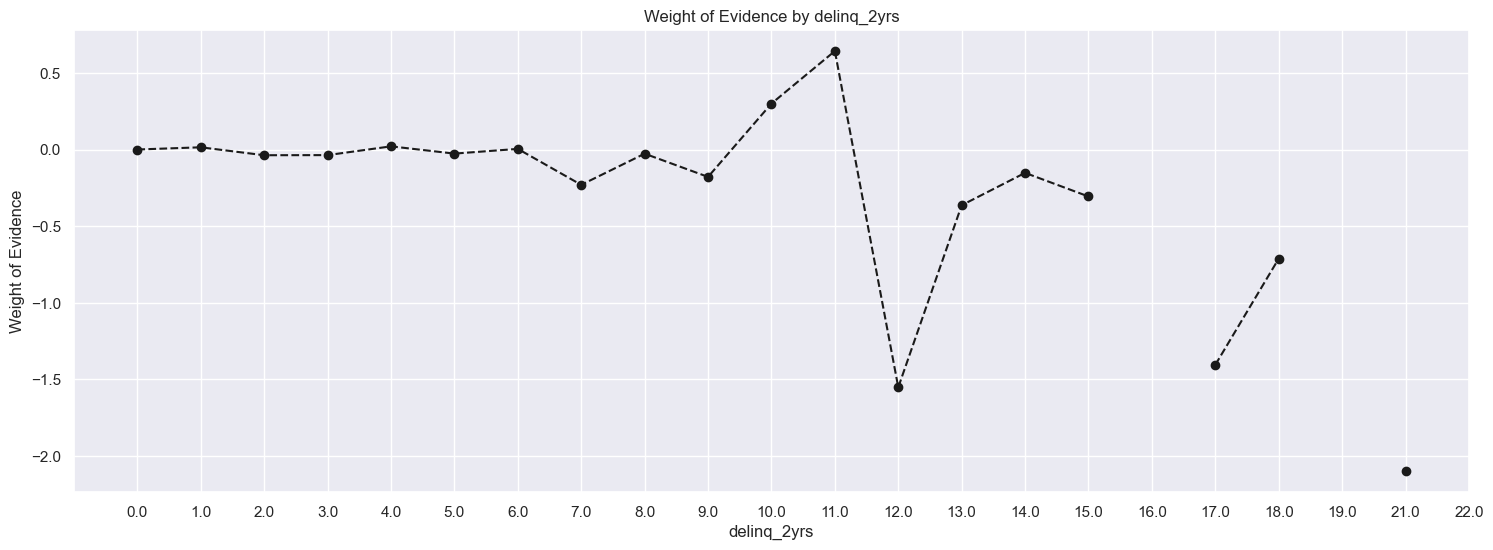

In [115]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'delinq_2yrs', df_targets_prepr)
plot_by_woe(df_temp)

In [116]:
df_inputs_prepr['delinq_2yrs:0'] = np.where((df_inputs_prepr['delinq_2yrs'] == 0), 1, 0)
df_inputs_prepr['delinq_2yrs:1-3'] = np.where((df_inputs_prepr['delinq_2yrs'] >= 1) & (df_inputs_prepr['delinq_2yrs'] <= 3), 1, 0)
df_inputs_prepr['delinq_2yrs:>=4'] = np.where((df_inputs_prepr['delinq_2yrs'] >= 9), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1336769168.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['delinq_2yrs:0'] = np.where((df_inputs_prepr['delinq_2yrs'] == 0), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1336769168.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['delinq_2yrs:1-3'] = np.where((df_inputs_prepr['delinq_2yrs'] >= 1) & (df_inputs_prepr['delinq_2yrs'] <= 3), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1336769168.py:3: PerformanceWarning: D

In [117]:
df_inputs_prepr_test['delinq_2yrs:0'] = np.where((df_inputs_prepr_test['delinq_2yrs'] == 0), 1, 0)
df_inputs_prepr_test['delinq_2yrs:1-3'] = np.where((df_inputs_prepr_test['delinq_2yrs'] >= 1) & (df_inputs_prepr_test['delinq_2yrs'] <= 3), 1, 0)
df_inputs_prepr_test['delinq_2yrs:>=4'] = np.where((df_inputs_prepr_test['delinq_2yrs'] >= 9), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1985796524.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['delinq_2yrs:0'] = np.where((df_inputs_prepr_test['delinq_2yrs'] == 0), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1985796524.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['delinq_2yrs:1-3'] = np.where((df_inputs_prepr_test['delinq_2yrs'] >= 1) & (df_inputs_prepr_test['delinq_2yrs'] <= 3), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1985796524.py

In [118]:
df_inputs_prepr_test.shape

(93257, 257)

C:\Users\kshit\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


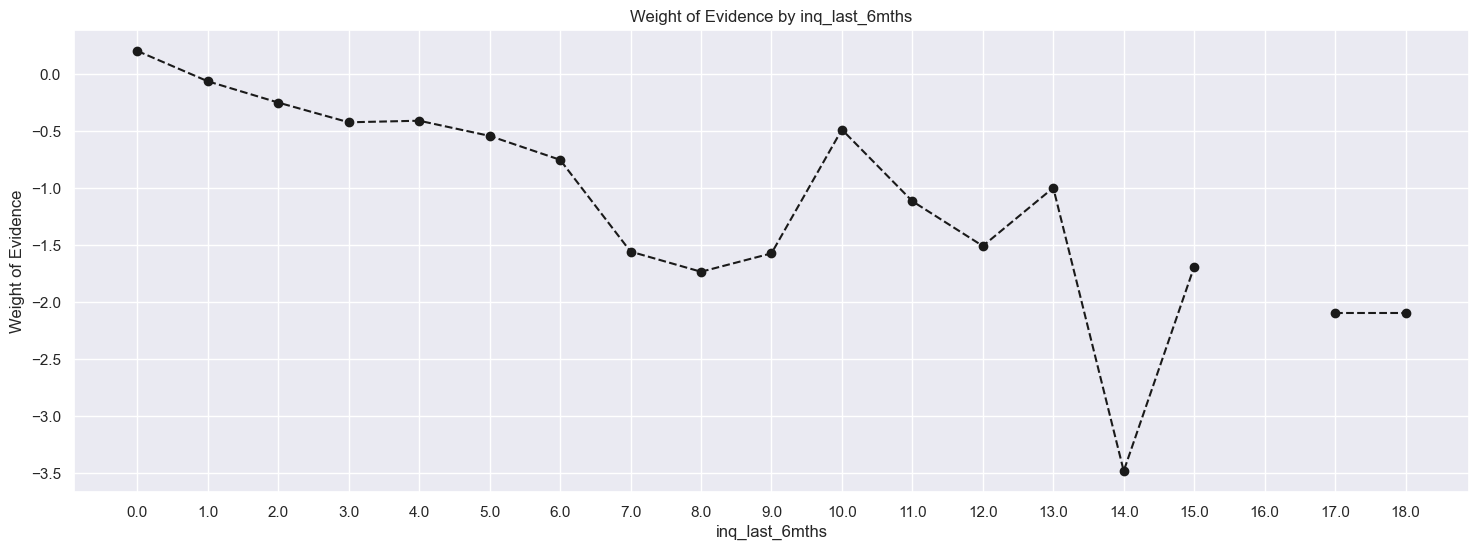

In [119]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'inq_last_6mths', df_targets_prepr)
plot_by_woe(df_temp)

In [120]:
df_inputs_prepr['inq_last_6mths:0'] = np.where((df_inputs_prepr['inq_last_6mths'] == 0), 1, 0)
df_inputs_prepr['inq_last_6mths:1-2'] = np.where((df_inputs_prepr['inq_last_6mths'] >= 1) & (df_inputs_prepr['inq_last_6mths'] <= 2), 1, 0)
df_inputs_prepr['inq_last_6mths:3-6'] = np.where((df_inputs_prepr['inq_last_6mths'] >= 3) & (df_inputs_prepr['inq_last_6mths'] <= 6), 1, 0)
df_inputs_prepr['inq_last_6mths:>6'] = np.where((df_inputs_prepr['inq_last_6mths'] > 6), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2247645943.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['inq_last_6mths:0'] = np.where((df_inputs_prepr['inq_last_6mths'] == 0), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2247645943.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['inq_last_6mths:1-2'] = np.where((df_inputs_prepr['inq_last_6mths'] >= 1) & (df_inputs_prepr['inq_last_6mths'] <= 2), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2247645943.py:3: Perfor

In [121]:
df_inputs_prepr_test['inq_last_6mths:0'] = np.where((df_inputs_prepr_test['inq_last_6mths'] == 0), 1, 0)
df_inputs_prepr_test['inq_last_6mths:1-2'] = np.where((df_inputs_prepr_test['inq_last_6mths'] >= 1) & (df_inputs_prepr_test['inq_last_6mths'] <= 2), 1, 0)
df_inputs_prepr_test['inq_last_6mths:3-6'] = np.where((df_inputs_prepr_test['inq_last_6mths'] >= 3) & (df_inputs_prepr_test['inq_last_6mths'] <= 6), 1, 0)
df_inputs_prepr_test['inq_last_6mths:>6'] = np.where((df_inputs_prepr_test['inq_last_6mths'] > 6), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1664109758.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['inq_last_6mths:0'] = np.where((df_inputs_prepr_test['inq_last_6mths'] == 0), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1664109758.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['inq_last_6mths:1-2'] = np.where((df_inputs_prepr_test['inq_last_6mths'] >= 1) & (df_inputs_prepr_test['inq_last_6mths'] <= 2), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_2020

In [122]:
df_inputs_prepr['open_acc'].unique()

array([ 5.,  7., 21., 11., 10., 14., 22.,  9.,  6., 16.,  3., 15.,  8.,
       17.,  4., 13., 18., 12., 20., 19., 30., 24., 26., 29., 41., 23.,
       28., 25.,  2., 34., 33., 27., 46., 32., 39., 50., 35., 36., 31.,
        1., 37., 47., 42.,  0., 45., 38., 40., 75., nan, 62., 43., 44.,
       49., 48., 76., 84., 51., 58., 52., 61., 53., 55., 54.])

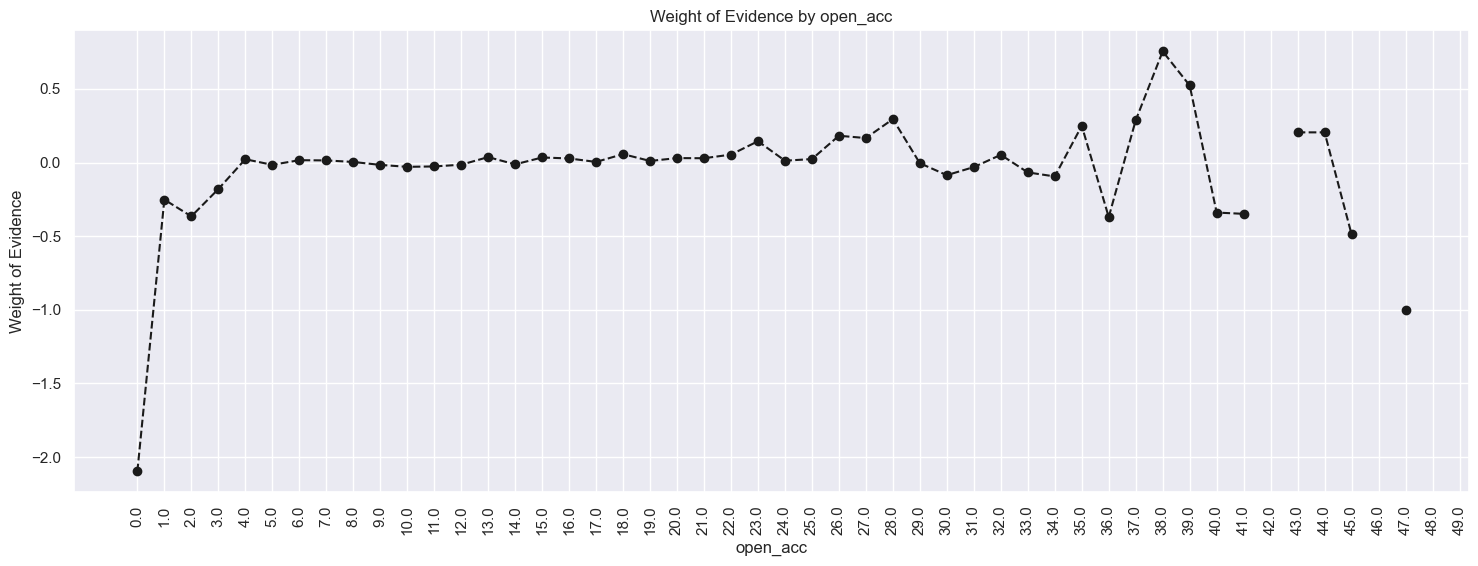

In [123]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'open_acc', df_targets_prepr)
plot_by_woe(df_temp, 90)


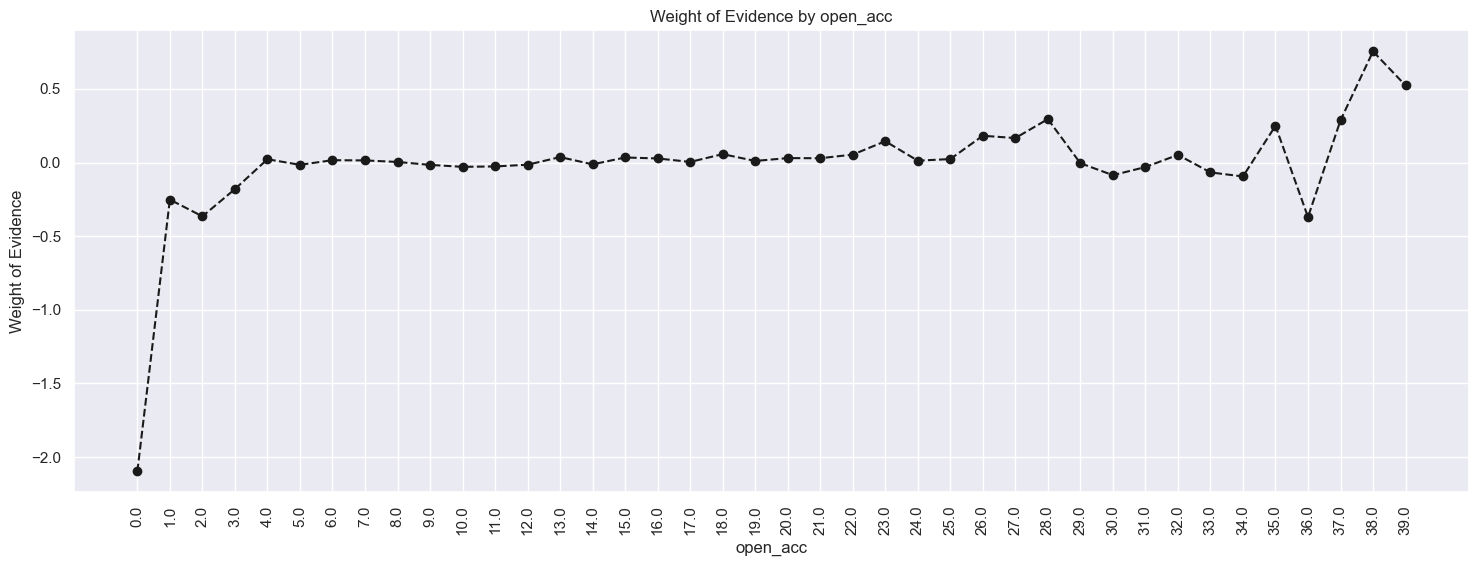

In [124]:
plot_by_woe(df_temp.iloc[ : 40, :], 90)

In [125]:
# Categories: '0', '1-3', '4-12', '13-17', '18-22', '23-25', '26-30', '>30'
df_inputs_prepr['open_acc:0'] = np.where((df_inputs_prepr['open_acc'] == 0), 1, 0)
df_inputs_prepr['open_acc:1-3'] = np.where((df_inputs_prepr['open_acc'] >= 1) & (df_inputs_prepr['open_acc'] <= 3), 1, 0)
df_inputs_prepr['open_acc:4-12'] = np.where((df_inputs_prepr['open_acc'] >= 4) & (df_inputs_prepr['open_acc'] <= 12), 1, 0)
df_inputs_prepr['open_acc:13-17'] = np.where((df_inputs_prepr['open_acc'] >= 13) & (df_inputs_prepr['open_acc'] <= 17), 1, 0)
df_inputs_prepr['open_acc:18-22'] = np.where((df_inputs_prepr['open_acc'] >= 18) & (df_inputs_prepr['open_acc'] <= 22), 1, 0)
df_inputs_prepr['open_acc:23-25'] = np.where((df_inputs_prepr['open_acc'] >= 23) & (df_inputs_prepr['open_acc'] <= 25), 1, 0)
df_inputs_prepr['open_acc:26-30'] = np.where((df_inputs_prepr['open_acc'] >= 26) & (df_inputs_prepr['open_acc'] <= 30), 1, 0)
df_inputs_prepr['open_acc:>=31'] = np.where((df_inputs_prepr['open_acc'] >= 31), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1163336257.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['open_acc:0'] = np.where((df_inputs_prepr['open_acc'] == 0), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1163336257.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['open_acc:1-3'] = np.where((df_inputs_prepr['open_acc'] >= 1) & (df_inputs_prepr['open_acc'] <= 3), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1163336257.py:4: PerformanceWarning: DataFrame is hig

In [126]:
df_inputs_prepr_test['open_acc:0'] = np.where((df_inputs_prepr_test['open_acc'] == 0), 1, 0)
df_inputs_prepr_test['open_acc:1-3'] = np.where((df_inputs_prepr_test['open_acc'] >= 1) & (df_inputs_prepr_test['open_acc'] <= 3), 1, 0)
df_inputs_prepr_test['open_acc:4-12'] = np.where((df_inputs_prepr_test['open_acc'] >= 4) & (df_inputs_prepr_test['open_acc'] <= 12), 1, 0)
df_inputs_prepr_test['open_acc:13-17'] = np.where((df_inputs_prepr_test['open_acc'] >= 13) & (df_inputs_prepr_test['open_acc'] <= 17), 1, 0)
df_inputs_prepr_test['open_acc:18-22'] = np.where((df_inputs_prepr_test['open_acc'] >= 18) & (df_inputs_prepr_test['open_acc'] <= 22), 1, 0)
df_inputs_prepr_test['open_acc:23-25'] = np.where((df_inputs_prepr_test['open_acc'] >= 23) & (df_inputs_prepr_test['open_acc'] <= 25), 1, 0)
df_inputs_prepr_test['open_acc:26-30'] = np.where((df_inputs_prepr_test['open_acc'] >= 26) & (df_inputs_prepr_test['open_acc'] <= 30), 1, 0)
df_inputs_prepr_test['open_acc:>=31'] = np.where((df_inputs_prepr_test['open_acc'] >= 31), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2533126240.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['open_acc:0'] = np.where((df_inputs_prepr_test['open_acc'] == 0), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2533126240.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['open_acc:1-3'] = np.where((df_inputs_prepr_test['open_acc'] >= 1) & (df_inputs_prepr_test['open_acc'] <= 3), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2533126240.py:3: Performance

In [127]:
df_inputs_prepr['pub_rec'].unique()

array([ 0.,  1.,  2.,  4.,  3.,  7.,  6.,  5.,  9., nan,  8., 10., 18.,
       34., 12., 11., 17., 40., 16., 54., 13., 63., 49., 19., 15., 14.])

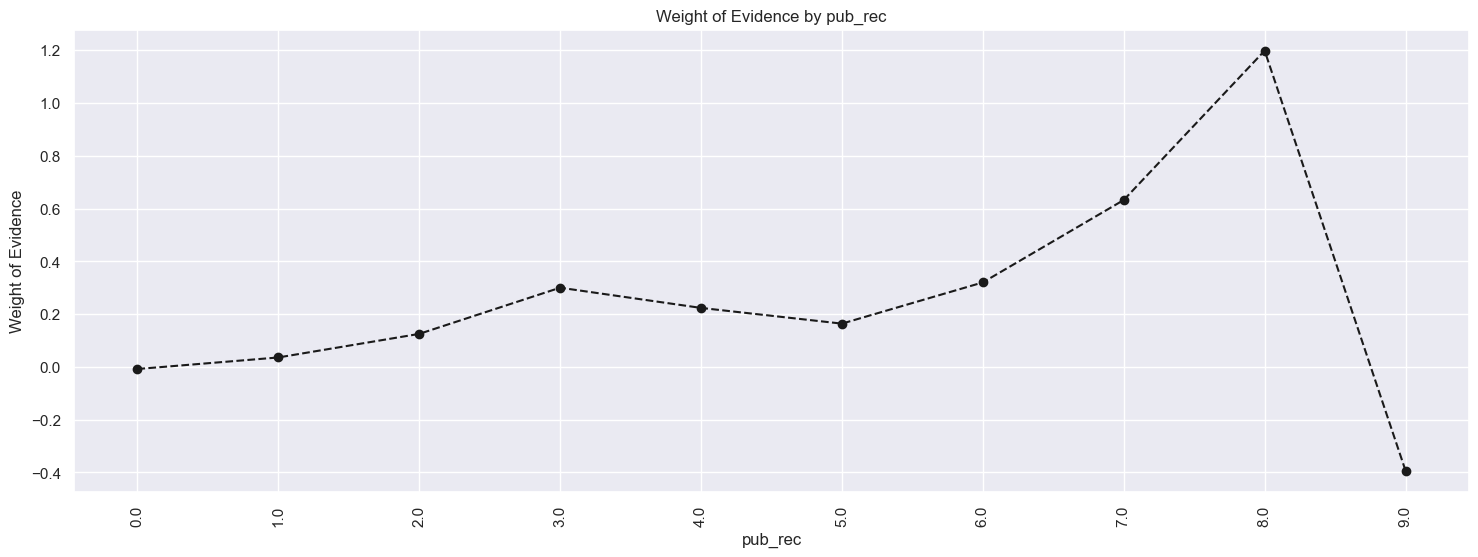

In [128]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'pub_rec', df_targets_prepr)
plot_by_woe(df_temp, 90)

In [129]:
df_inputs_prepr['pub_rec:0-2'] = np.where((df_inputs_prepr['pub_rec'] >= 0) & (df_inputs_prepr['pub_rec'] <= 2), 1, 0)
df_inputs_prepr['pub_rec:3-4'] = np.where((df_inputs_prepr['pub_rec'] >= 3) & (df_inputs_prepr['pub_rec'] <= 4), 1, 0)
df_inputs_prepr['pub_rec:>=5'] = np.where((df_inputs_prepr['pub_rec'] >= 5), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3802196886.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['pub_rec:0-2'] = np.where((df_inputs_prepr['pub_rec'] >= 0) & (df_inputs_prepr['pub_rec'] <= 2), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3802196886.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['pub_rec:3-4'] = np.where((df_inputs_prepr['pub_rec'] >= 3) & (df_inputs_prepr['pub_rec'] <= 4), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3802196886.py:3: Per

In [130]:
df_inputs_prepr_test['pub_rec:0-2'] = np.where((df_inputs_prepr_test['pub_rec'] >= 0) & (df_inputs_prepr_test['pub_rec'] <= 2), 1, 0)
df_inputs_prepr_test['pub_rec:3-4'] = np.where((df_inputs_prepr_test['pub_rec'] >= 3) & (df_inputs_prepr_test['pub_rec'] <= 4), 1, 0)
df_inputs_prepr_test['pub_rec:>=5'] = np.where((df_inputs_prepr_test['pub_rec'] >= 5), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1616549244.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['pub_rec:0-2'] = np.where((df_inputs_prepr_test['pub_rec'] >= 0) & (df_inputs_prepr_test['pub_rec'] <= 2), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1616549244.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['pub_rec:3-4'] = np.where((df_inputs_prepr_test['pub_rec'] >= 3) & (df_inputs_prepr_test['pub_rec'] <= 4), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipyker

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1771722680.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_acc_factor'] = pd.cut(df_inputs_prepr['total_acc'], 50)


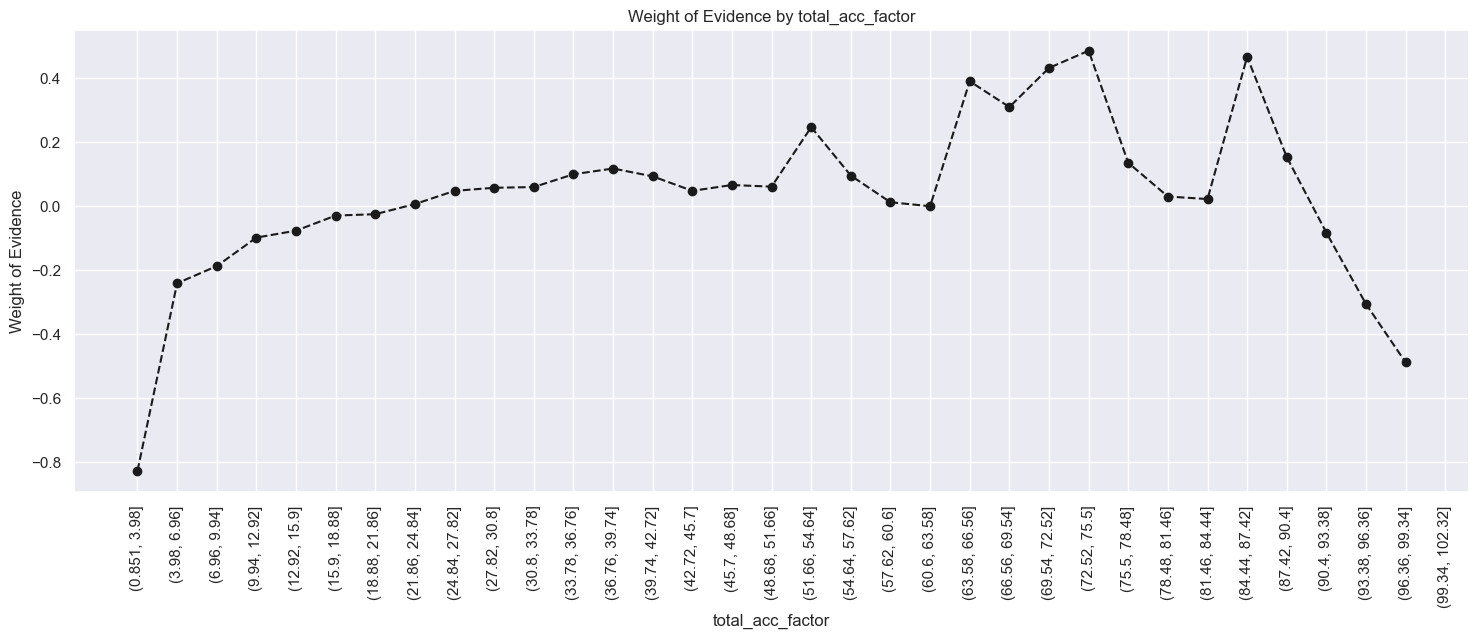

In [131]:
df_inputs_prepr['total_acc_factor'] = pd.cut(df_inputs_prepr['total_acc'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'total_acc_factor', df_targets_prepr)
plot_by_woe(df_temp, 90)

In [132]:
bin_edges = df_inputs_prepr['total_acc_factor'].cat.categories
df_inputs_prepr_test['total_acc_factor'] = pd.cut(df_inputs_prepr_test['total_acc'], bins=bin_edges)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2018333582.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['total_acc_factor'] = pd.cut(df_inputs_prepr_test['total_acc'], bins=bin_edges)


In [133]:
df_inputs_prepr['total_acc:<=27'] = np.where((df_inputs_prepr['total_acc'] <= 27), 1, 0)
df_inputs_prepr['total_acc:28-51'] = np.where((df_inputs_prepr['total_acc'] >= 28) & (df_inputs_prepr['total_acc'] <= 51), 1, 0)
df_inputs_prepr['total_acc:>=52'] = np.where((df_inputs_prepr['total_acc'] >= 52), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1572042135.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_acc:<=27'] = np.where((df_inputs_prepr['total_acc'] <= 27), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1572042135.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_acc:28-51'] = np.where((df_inputs_prepr['total_acc'] >= 28) & (df_inputs_prepr['total_acc'] <= 51), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1572042135.py:3: PerformanceWarning: Dat

In [134]:
df_inputs_prepr_test['total_acc:<=27'] = np.where((df_inputs_prepr_test['total_acc'] <= 27), 1, 0)
df_inputs_prepr_test['total_acc:28-51'] = np.where((df_inputs_prepr_test['total_acc'] >= 28) & (df_inputs_prepr_test['total_acc'] <= 51), 1, 0)
df_inputs_prepr_test['total_acc:>=52'] = np.where((df_inputs_prepr_test['total_acc'] >= 52), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\4099132794.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['total_acc:<=27'] = np.where((df_inputs_prepr_test['total_acc'] <= 27), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\4099132794.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['total_acc:28-51'] = np.where((df_inputs_prepr_test['total_acc'] >= 28) & (df_inputs_prepr_test['total_acc'] <= 51), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\4099132794.py:3

In [135]:
df_inputs_prepr['acc_now_delinq'].unique()

array([ 0.,  1.,  2., nan,  3.,  4.,  5.])

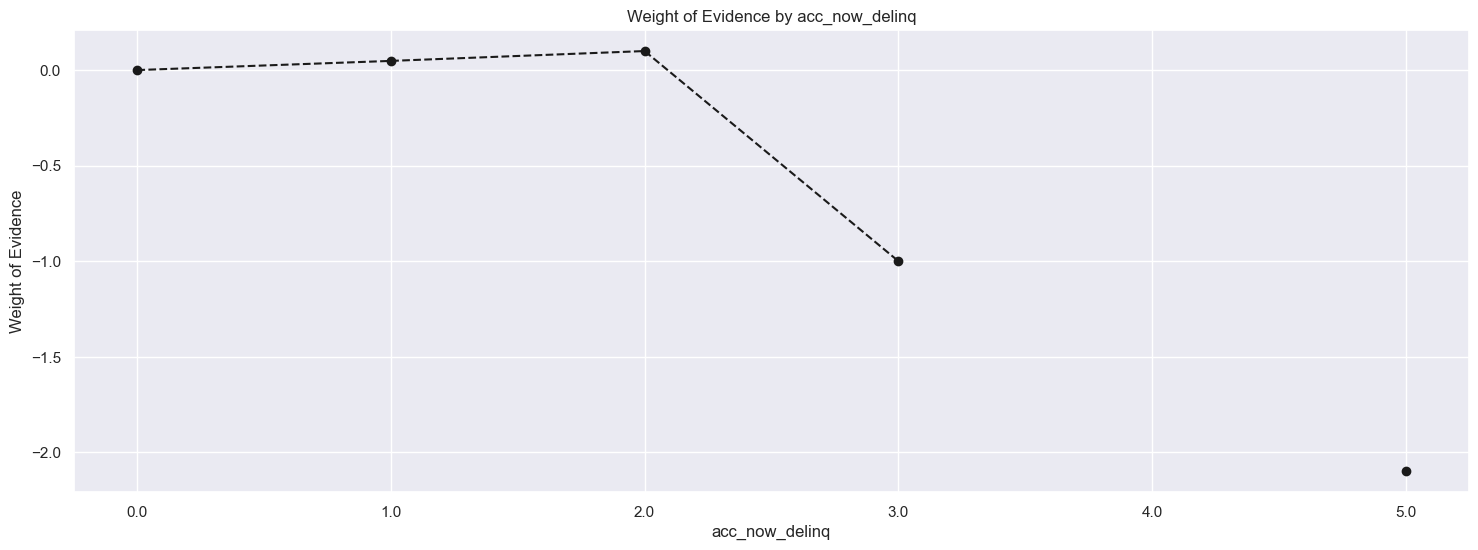

In [136]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'acc_now_delinq', df_targets_prepr)
plot_by_woe(df_temp)

In [137]:
df_inputs_prepr['acc_now_delinq:0'] = np.where((df_inputs_prepr['acc_now_delinq'] == 0), 1, 0)
df_inputs_prepr['acc_now_delinq:>=1'] = np.where((df_inputs_prepr['acc_now_delinq'] >= 1), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2134325986.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['acc_now_delinq:0'] = np.where((df_inputs_prepr['acc_now_delinq'] == 0), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2134325986.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['acc_now_delinq:>=1'] = np.where((df_inputs_prepr['acc_now_delinq'] >= 1), 1, 0)


In [138]:
df_inputs_prepr_test['acc_now_delinq:0'] = np.where((df_inputs_prepr_test['acc_now_delinq'] == 0), 1, 0)
df_inputs_prepr_test['acc_now_delinq:>=1'] = np.where((df_inputs_prepr_test['acc_now_delinq'] >= 1), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2325416708.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['acc_now_delinq:0'] = np.where((df_inputs_prepr_test['acc_now_delinq'] == 0), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2325416708.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['acc_now_delinq:>=1'] = np.where((df_inputs_prepr_test['acc_now_delinq'] >= 1), 1, 0)


In [139]:
df_inputs_prepr['total_rev_hi_lim'].unique().shape

(12309,)

In [140]:
df_inputs_prepr['total_rev_hi_lim_factor'] = pd.cut(df_inputs_prepr['total_rev_hi_lim'], 2000)
# Here we do fine-classing: using the 'cut' method, we split the variable into 2000 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'total_rev_hi_lim_factor', df_targets_prepr)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\235243998.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_rev_hi_lim_factor'] = pd.cut(df_inputs_prepr['total_rev_hi_lim'], 2000)
C:\Users\kshit\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [141]:
bin_edges = df_inputs_prepr['total_rev_hi_lim_factor'].cat.categories
df_inputs_prepr_test['total_rev_hi_lim_factor'] = pd.cut(df_inputs_prepr_test['total_rev_hi_lim'], bins=bin_edges)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3081475474.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['total_rev_hi_lim_factor'] = pd.cut(df_inputs_prepr_test['total_rev_hi_lim'], bins=bin_edges)


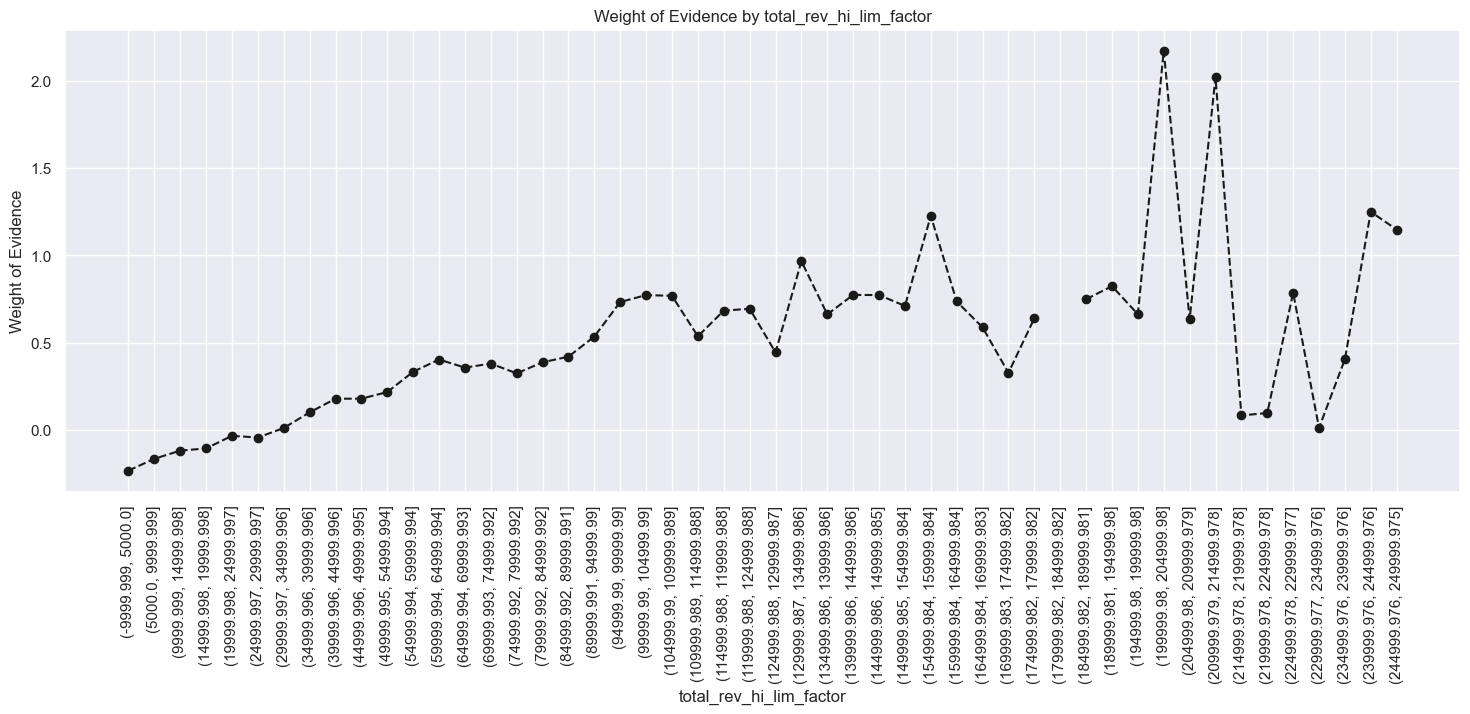

In [142]:
plot_by_woe(df_temp.iloc[: 50, : ], 90)
# plot_by_woe(df_temp)



In [143]:
df_inputs_prepr['total_rev_hi_lim:<=5K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] <= 5000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:5K-10K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 5000) & (df_inputs_prepr['total_rev_hi_lim'] <= 10000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:10K-20K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 10000) & (df_inputs_prepr['total_rev_hi_lim'] <= 20000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:20K-30K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 20000) & (df_inputs_prepr['total_rev_hi_lim'] <= 30000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:30K-40K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 30000) & (df_inputs_prepr['total_rev_hi_lim'] <= 40000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:40K-55K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 40000) & (df_inputs_prepr['total_rev_hi_lim'] <= 55000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:55K-95K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 55000) & (df_inputs_prepr['total_rev_hi_lim'] <= 95000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:>95K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 95000), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1572597749.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_rev_hi_lim:<=5K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] <= 5000), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1572597749.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_rev_hi_lim:5K-10K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 5000) & (df_inputs_prepr['total_rev_hi_lim'] <= 10000), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_2020

In [144]:
df_inputs_prepr_test['total_rev_hi_lim:<=5K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] <= 5000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:5K-10K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 5000) & (df_inputs_prepr_test['total_rev_hi_lim'] <= 10000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:10K-20K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 10000) & (df_inputs_prepr_test['total_rev_hi_lim'] <= 20000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:20K-30K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 20000) & (df_inputs_prepr_test['total_rev_hi_lim'] <= 30000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:30K-40K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 30000) & (df_inputs_prepr_test['total_rev_hi_lim'] <= 40000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:40K-55K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 40000) & (df_inputs_prepr_test['total_rev_hi_lim'] <= 55000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:55K-95K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 55000) & (df_inputs_prepr_test['total_rev_hi_lim'] <= 95000), 1, 0)
df_inputs_prepr_test['total_rev_hi_lim:>95K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 95000), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3151529557.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['total_rev_hi_lim:<=5K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] <= 5000), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3151529557.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['total_rev_hi_lim:5K-10K'] = np.where((df_inputs_prepr_test['total_rev_hi_lim'] > 5000) & (df_inputs_prepr_test['total_rev_hi_lim'] <= 10000), 1, 0)
C:\Users\kshit\AppData\

In [145]:
df_inputs_prepr['installment'].unique()

array([586.91, 258.71, 607.72, ..., 153.07, 757.02, 660.59],
      shape=(51366,))

In [146]:
df_inputs_prepr['installment_factor'] = pd.cut(df_inputs_prepr['installment'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'installment_factor', df_targets_prepr)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2958019633.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['installment_factor'] = pd.cut(df_inputs_prepr['installment'], 50)


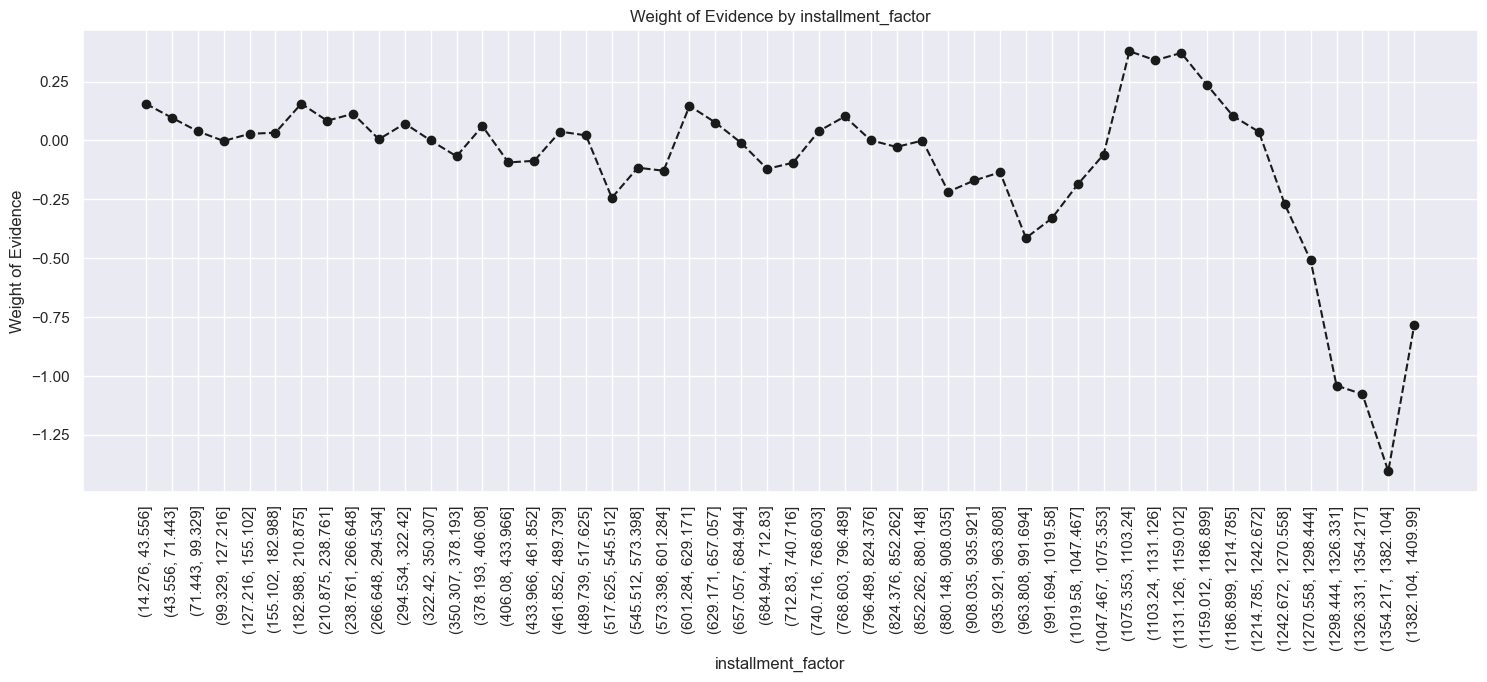

In [147]:
plot_by_woe(df_temp, 90)

In [148]:
bin_edges = df_inputs_prepr['installment_factor'].cat.categories
df_inputs_prepr_test['installment_factor'] = pd.cut(df_inputs_prepr_test['installment'], bins=bin_edges)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1528350180.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['installment_factor'] = pd.cut(df_inputs_prepr_test['installment'], bins=bin_edges)


In [149]:
df_inputs_prepr['annual_inc_factor'] = pd.cut(df_inputs_prepr['annual_inc'], 100)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'annual_inc_factor', df_targets_prepr)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1279788145.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['annual_inc_factor'] = pd.cut(df_inputs_prepr['annual_inc'], 100)


In [150]:
bin_edges = df_inputs_prepr['annual_inc_factor'].cat.categories

In [151]:
df_inputs_prepr_test['annual_inc_factor'] = pd.cut(df_inputs_prepr_test['annual_inc'], bins=bin_edges)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\774940548.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['annual_inc_factor'] = pd.cut(df_inputs_prepr_test['annual_inc'], bins=bin_edges)


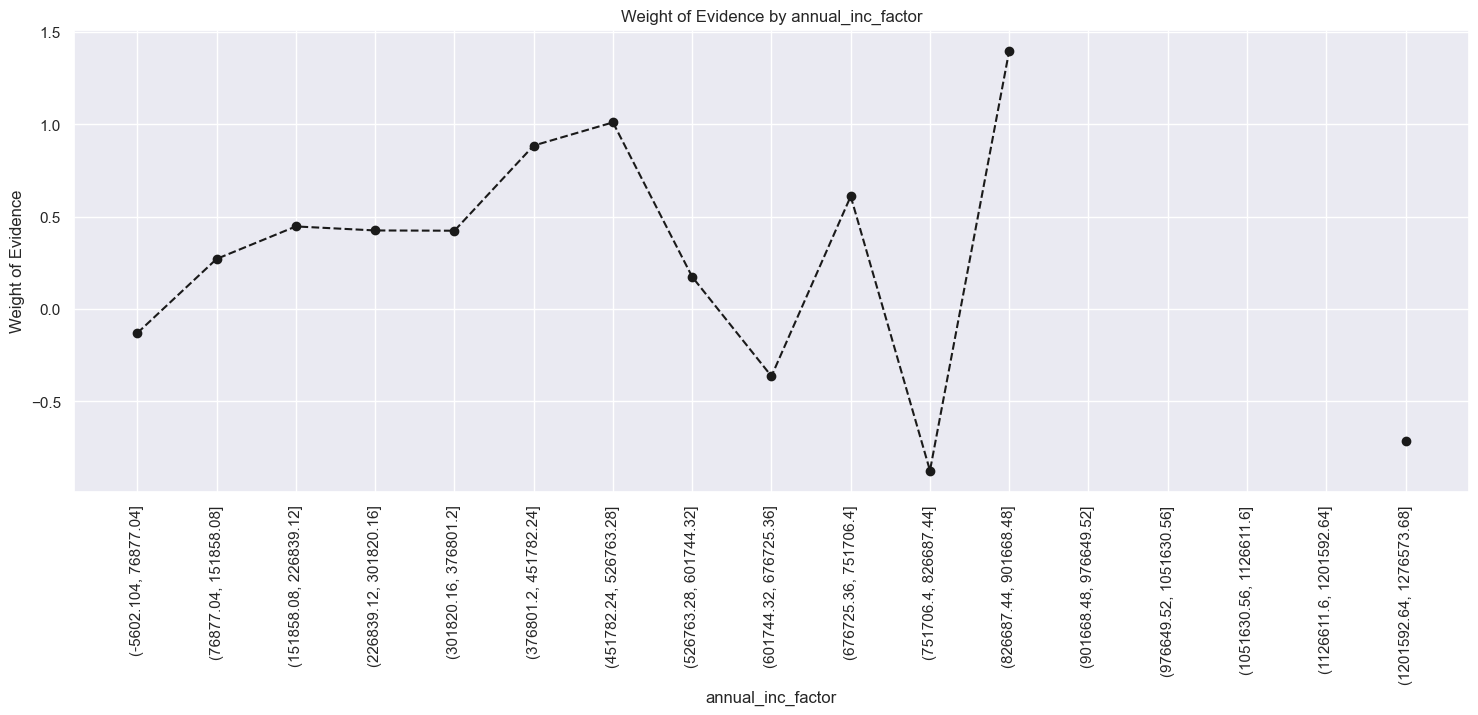

In [152]:
plot_by_woe(df_temp, 90)

In [153]:
df_inputs_prepr_temp = df_inputs_prepr.loc[df_inputs_prepr['annual_inc'] <= 140000, : ]

In [154]:
df_inputs_prepr_temp["annual_inc_factor"] = pd.cut(df_inputs_prepr_temp['annual_inc'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'annual_inc_factor', df_targets_prepr[df_inputs_prepr_temp.index])

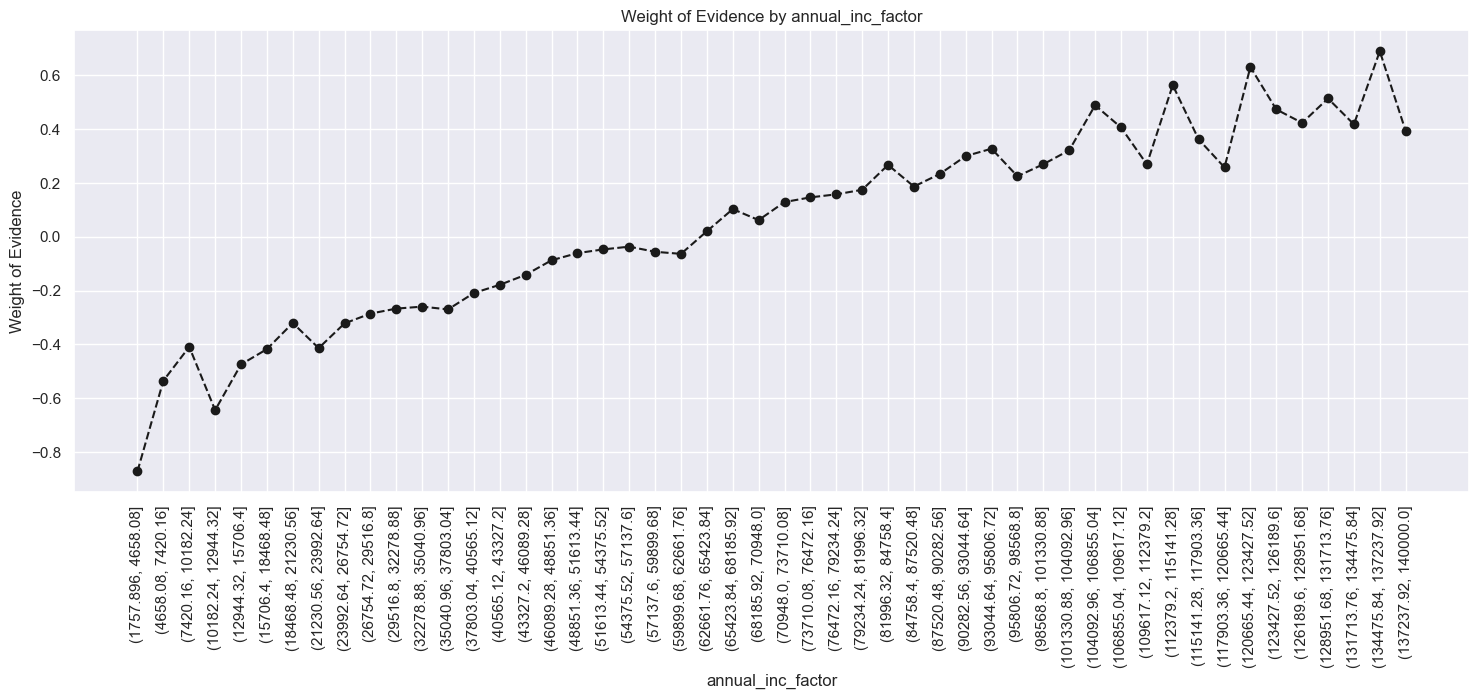

In [155]:
plot_by_woe(df_temp, 90)

In [156]:
df_inputs_prepr['annual_inc:<20K'] = np.where((df_inputs_prepr['annual_inc'] <= 20000), 1, 0)
df_inputs_prepr['annual_inc:20K-30K'] = np.where((df_inputs_prepr['annual_inc'] > 20000) & (df_inputs_prepr['annual_inc'] <= 30000), 1, 0)
df_inputs_prepr['annual_inc:30K-40K'] = np.where((df_inputs_prepr['annual_inc'] > 30000) & (df_inputs_prepr['annual_inc'] <= 40000), 1, 0)
df_inputs_prepr['annual_inc:40K-50K'] = np.where((df_inputs_prepr['annual_inc'] > 40000) & (df_inputs_prepr['annual_inc'] <= 50000), 1, 0)
df_inputs_prepr['annual_inc:50K-60K'] = np.where((df_inputs_prepr['annual_inc'] > 50000) & (df_inputs_prepr['annual_inc'] <= 60000), 1, 0)
df_inputs_prepr['annual_inc:60K-70K'] = np.where((df_inputs_prepr['annual_inc'] > 60000) & (df_inputs_prepr['annual_inc'] <= 70000), 1, 0)
df_inputs_prepr['annual_inc:70K-80K'] = np.where((df_inputs_prepr['annual_inc'] > 70000) & (df_inputs_prepr['annual_inc'] <= 80000), 1, 0)
df_inputs_prepr['annual_inc:80K-90K'] = np.where((df_inputs_prepr['annual_inc'] > 80000) & (df_inputs_prepr['annual_inc'] <= 90000), 1, 0)
df_inputs_prepr['annual_inc:90K-100K'] = np.where((df_inputs_prepr['annual_inc'] > 90000) & (df_inputs_prepr['annual_inc'] <= 100000), 1, 0)
df_inputs_prepr['annual_inc:100K-120K'] = np.where((df_inputs_prepr['annual_inc'] > 100000) & (df_inputs_prepr['annual_inc'] <= 120000), 1, 0)
df_inputs_prepr['annual_inc:120K-140K'] = np.where((df_inputs_prepr['annual_inc'] > 120000) & (df_inputs_prepr['annual_inc'] <= 140000), 1, 0)
df_inputs_prepr['annual_inc:>140K'] = np.where((df_inputs_prepr['annual_inc'] > 140000), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\932304449.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['annual_inc:<20K'] = np.where((df_inputs_prepr['annual_inc'] <= 20000), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\932304449.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['annual_inc:20K-30K'] = np.where((df_inputs_prepr['annual_inc'] > 20000) & (df_inputs_prepr['annual_inc'] <= 30000), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\932304449.py:3: Performance

In [157]:
df_inputs_prepr_test['annual_inc:<20K'] = np.where((df_inputs_prepr_test['annual_inc'] <= 20000), 1, 0)
df_inputs_prepr_test['annual_inc:20K-30K'] = np.where((df_inputs_prepr_test['annual_inc'] > 20000) & (df_inputs_prepr_test['annual_inc'] <= 30000), 1, 0)
df_inputs_prepr_test['annual_inc:30K-40K'] = np.where((df_inputs_prepr_test['annual_inc'] > 30000) & (df_inputs_prepr_test['annual_inc'] <= 40000), 1, 0)
df_inputs_prepr_test['annual_inc:40K-50K'] = np.where((df_inputs_prepr_test['annual_inc'] > 40000) & (df_inputs_prepr_test['annual_inc'] <= 50000), 1, 0)
df_inputs_prepr_test['annual_inc:50K-60K'] = np.where((df_inputs_prepr_test['annual_inc'] > 50000) & (df_inputs_prepr_test['annual_inc'] <= 60000), 1, 0)
df_inputs_prepr_test['annual_inc:60K-70K'] = np.where((df_inputs_prepr_test['annual_inc'] > 60000) & (df_inputs_prepr_test['annual_inc'] <= 70000), 1, 0)
df_inputs_prepr_test['annual_inc:70K-80K'] = np.where((df_inputs_prepr_test['annual_inc'] > 70000) & (df_inputs_prepr_test['annual_inc'] <= 80000), 1, 0)
df_inputs_prepr_test['annual_inc:80K-90K'] = np.where((df_inputs_prepr_test['annual_inc'] > 80000) & (df_inputs_prepr_test['annual_inc'] <= 90000), 1, 0)
df_inputs_prepr_test['annual_inc:90K-100K'] = np.where((df_inputs_prepr_test['annual_inc'] > 90000) & (df_inputs_prepr_test['annual_inc'] <= 100000), 1, 0)
df_inputs_prepr_test['annual_inc:100K-120K'] = np.where((df_inputs_prepr_test['annual_inc'] > 100000) & (df_inputs_prepr_test['annual_inc'] <= 120000), 1, 0)
df_inputs_prepr_test['annual_inc:120K-140K'] = np.where((df_inputs_prepr_test['annual_inc'] > 120000) & (df_inputs_prepr_test['annual_inc'] <= 140000), 1, 0)
df_inputs_prepr_test['annual_inc:>140K'] = np.where((df_inputs_prepr_test['annual_inc'] > 140000), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\348239508.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['annual_inc:<20K'] = np.where((df_inputs_prepr_test['annual_inc'] <= 20000), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\348239508.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['annual_inc:20K-30K'] = np.where((df_inputs_prepr_test['annual_inc'] > 20000) & (df_inputs_prepr_test['annual_inc'] <= 30000), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\34

In [158]:
df_inputs_prepr_temp = df_inputs_prepr[pd.notnull(df_inputs_prepr['mths_since_last_delinq'])]

In [159]:
df_inputs_prepr_temp['mths_since_last_delinq_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_delinq'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'mths_since_last_delinq_factor', df_targets_prepr[df_inputs_prepr_temp.index])

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2159120661.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_temp['mths_since_last_delinq_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_delinq'], 50)


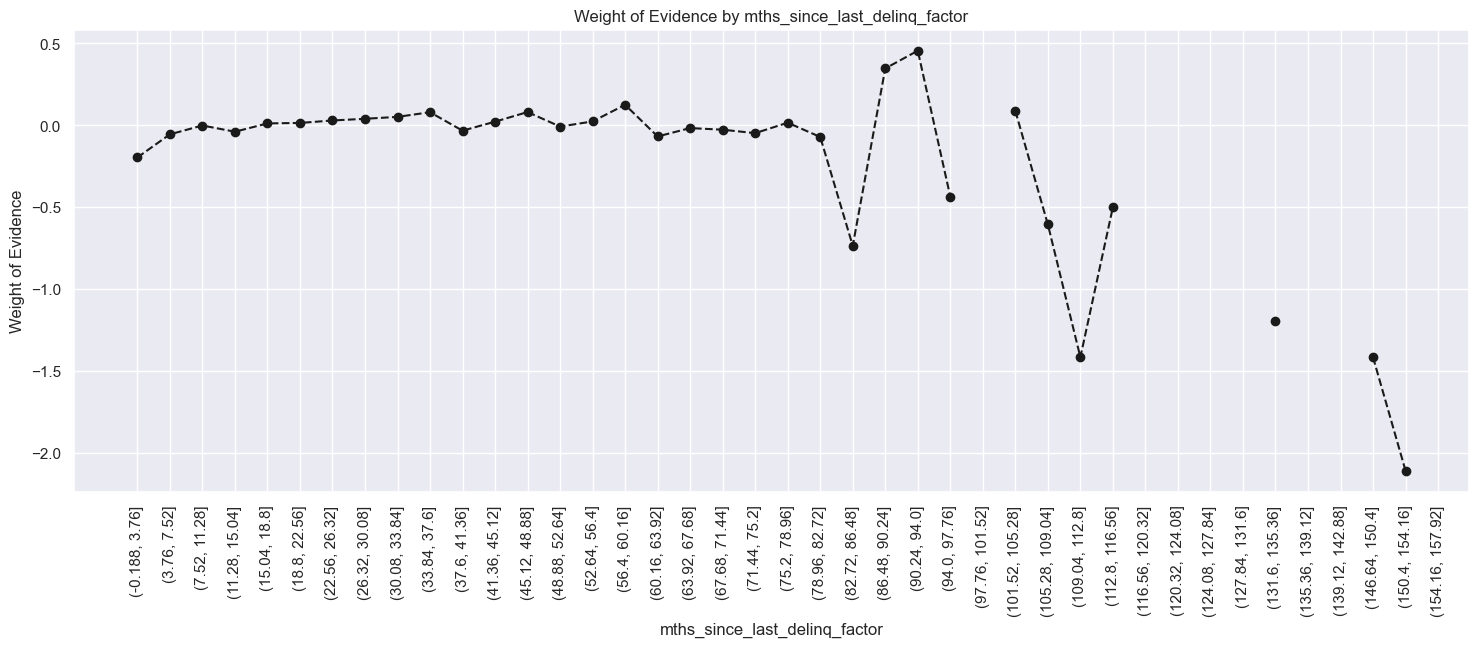

In [160]:
plot_by_woe(df_temp, 90)

In [161]:
df_inputs_prepr['mths_since_last_delinq:Missing'] = np.where((df_inputs_prepr['mths_since_last_delinq'].isnull()), 1, 0)
df_inputs_prepr['mths_since_last_delinq:0-3'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 0) & (df_inputs_prepr['mths_since_last_delinq'] <= 3), 1, 0)
df_inputs_prepr['mths_since_last_delinq:4-30'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 4) & (df_inputs_prepr['mths_since_last_delinq'] <= 30), 1, 0)
df_inputs_prepr['mths_since_last_delinq:31-56'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 31) & (df_inputs_prepr['mths_since_last_delinq'] <= 56), 1, 0)
df_inputs_prepr['mths_since_last_delinq:>=57'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 57), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2300411631.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_delinq:Missing'] = np.where((df_inputs_prepr['mths_since_last_delinq'].isnull()), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2300411631.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_delinq:0-3'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 0) & (df_inputs_prepr['mths_since_last_delinq'] <= 3), 1, 0)
C:\Users\kshit\AppData\

In [162]:
df_inputs_prepr_test['mths_since_last_delinq:Missing'] = np.where((df_inputs_prepr_test['mths_since_last_delinq'].isnull()), 1, 0)
df_inputs_prepr_test['mths_since_last_delinq:0-3'] = np.where((df_inputs_prepr_test['mths_since_last_delinq'] >= 0) & (df_inputs_prepr_test['mths_since_last_delinq'] <= 3), 1, 0)
df_inputs_prepr_test['mths_since_last_delinq:4-30'] = np.where((df_inputs_prepr_test['mths_since_last_delinq'] >= 4) & (df_inputs_prepr_test['mths_since_last_delinq'] <= 30), 1, 0)
df_inputs_prepr_test['mths_since_last_delinq:31-56'] = np.where((df_inputs_prepr_test['mths_since_last_delinq'] >= 31) & (df_inputs_prepr_test['mths_since_last_delinq'] <= 56), 1, 0)
df_inputs_prepr_test['mths_since_last_delinq:>=57'] = np.where((df_inputs_prepr_test['mths_since_last_delinq'] >= 57), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1754351029.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['mths_since_last_delinq:Missing'] = np.where((df_inputs_prepr_test['mths_since_last_delinq'].isnull()), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1754351029.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['mths_since_last_delinq:0-3'] = np.where((df_inputs_prepr_test['mths_since_last_delinq'] >= 0) & (df_inputs_prepr_test['mths_since_last_delinq'] <= 3), 1, 0

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\1009794494.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti_factor'] = pd.cut(df_inputs_prepr['dti'], 100)


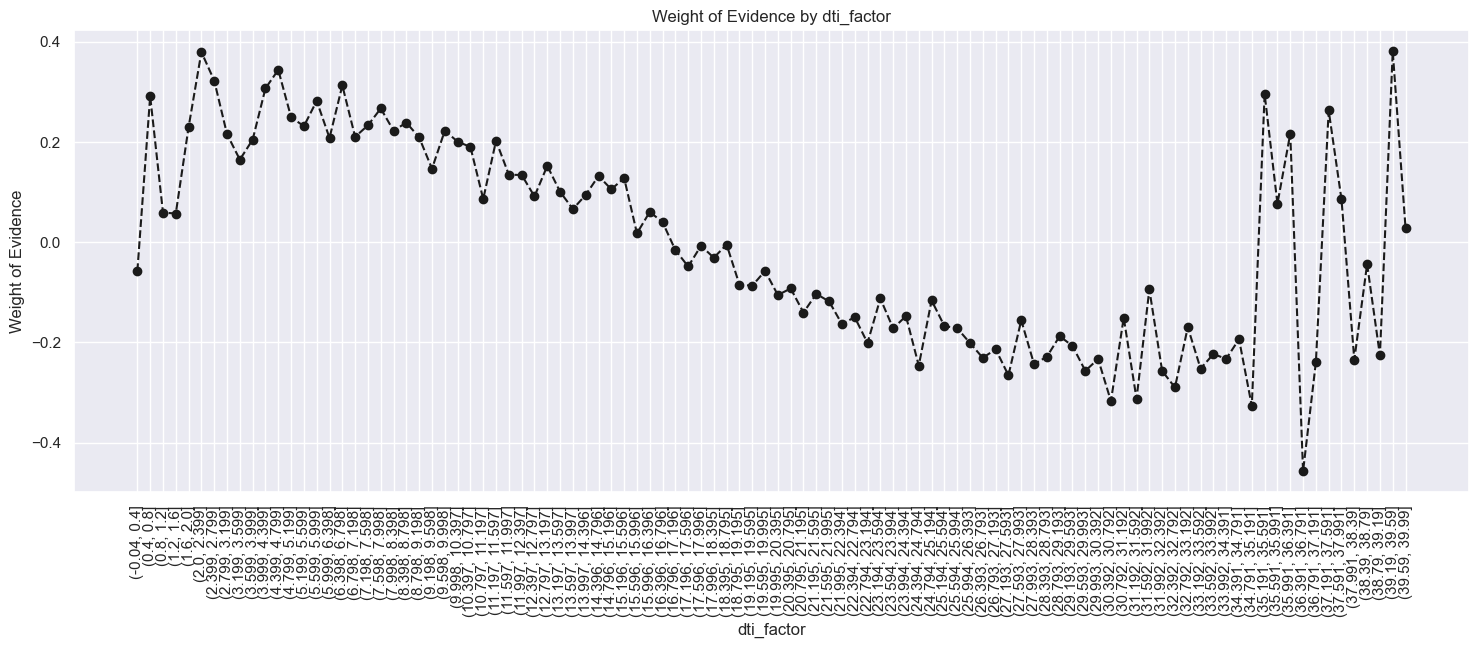

In [163]:
df_inputs_prepr['dti_factor'] = pd.cut(df_inputs_prepr['dti'], 100)
# Here we do fine-classing: using the 'cut' method, we split the variable into 100 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'dti_factor', df_targets_prepr)
plot_by_woe(df_temp, 90)

In [164]:
bin_edges = df_inputs_prepr['dti_factor'].cat.categories
df_inputs_prepr_test['dti_factor'] = pd.cut(df_inputs_prepr_test['dti'], bins=bin_edges)


C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2003139745.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['dti_factor'] = pd.cut(df_inputs_prepr_test['dti'], bins=bin_edges)


In [165]:
df_inputs_prepr_temp = df_inputs_prepr.loc[df_inputs_prepr['dti'] <= 35, : ]

In [166]:
df_inputs_prepr_temp['dti_factor'] = pd.cut(df_inputs_prepr_temp['dti'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'dti_factor', df_targets_prepr[df_inputs_prepr_temp.index])

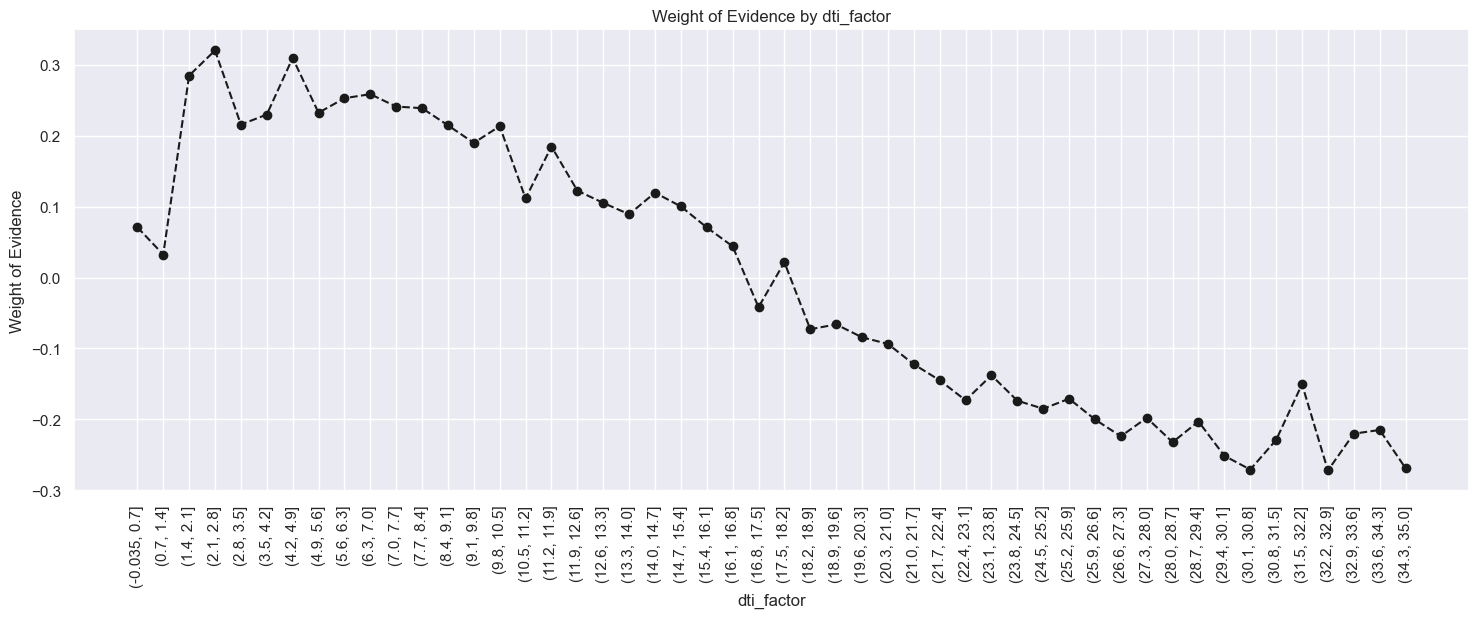

In [167]:
plot_by_woe(df_temp, 90)

In [168]:
df_inputs_prepr['dti:<=1.4'] = np.where((df_inputs_prepr['dti'] <= 1.4), 1, 0)
df_inputs_prepr['dti:1.4-3.5'] = np.where((df_inputs_prepr['dti'] > 1.4) & (df_inputs_prepr['dti'] <= 3.5), 1, 0)
df_inputs_prepr['dti:3.5-7.7'] = np.where((df_inputs_prepr['dti'] > 3.5) & (df_inputs_prepr['dti'] <= 7.7), 1, 0)
df_inputs_prepr['dti:7.7-10.5'] = np.where((df_inputs_prepr['dti'] > 7.7) & (df_inputs_prepr['dti'] <= 10.5), 1, 0)
df_inputs_prepr['dti:10.5-16.1'] = np.where((df_inputs_prepr['dti'] > 10.5) & (df_inputs_prepr['dti'] <= 16.1), 1, 0)
df_inputs_prepr['dti:16.1-20.3'] = np.where((df_inputs_prepr['dti'] > 16.1) & (df_inputs_prepr['dti'] <= 20.3), 1, 0)
df_inputs_prepr['dti:20.3-21.7'] = np.where((df_inputs_prepr['dti'] > 20.3) & (df_inputs_prepr['dti'] <= 21.7), 1, 0)
df_inputs_prepr['dti:21.7-22.4'] = np.where((df_inputs_prepr['dti'] > 21.7) & (df_inputs_prepr['dti'] <= 22.4), 1, 0)
df_inputs_prepr['dti:22.4-35'] = np.where((df_inputs_prepr['dti'] > 22.4) & (df_inputs_prepr['dti'] <= 35), 1, 0)
df_inputs_prepr['dti:>35'] = np.where((df_inputs_prepr['dti'] > 35), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3828360169.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti:<=1.4'] = np.where((df_inputs_prepr['dti'] <= 1.4), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3828360169.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti:1.4-3.5'] = np.where((df_inputs_prepr['dti'] > 1.4) & (df_inputs_prepr['dti'] <= 3.5), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\3828360169.py:3: PerformanceWarning: DataFrame is highly fragment

In [169]:
df_inputs_prepr_test['dti:<=1.4'] = np.where((df_inputs_prepr_test['dti'] <= 1.4), 1, 0)
df_inputs_prepr_test['dti:1.4-3.5'] = np.where((df_inputs_prepr_test['dti'] > 1.4) & (df_inputs_prepr_test['dti'] <= 3.5), 1, 0)
df_inputs_prepr_test['dti:3.5-7.7'] = np.where((df_inputs_prepr_test['dti'] > 3.5) & (df_inputs_prepr_test['dti'] <= 7.7), 1, 0)
df_inputs_prepr_test['dti:7.7-10.5'] = np.where((df_inputs_prepr_test['dti'] > 7.7) & (df_inputs_prepr_test['dti'] <= 10.5), 1, 0)
df_inputs_prepr_test['dti:10.5-16.1'] = np.where((df_inputs_prepr_test['dti'] > 10.5) & (df_inputs_prepr_test['dti'] <= 16.1), 1, 0)
df_inputs_prepr_test['dti:16.1-20.3'] = np.where((df_inputs_prepr_test['dti'] > 16.1) & (df_inputs_prepr_test['dti'] <= 20.3), 1, 0)
df_inputs_prepr_test['dti:20.3-21.7'] = np.where((df_inputs_prepr_test['dti'] > 20.3) & (df_inputs_prepr_test['dti'] <= 21.7), 1, 0)
df_inputs_prepr_test['dti:21.7-22.4'] = np.where((df_inputs_prepr_test['dti'] > 21.7) & (df_inputs_prepr_test['dti'] <= 22.4), 1, 0)
df_inputs_prepr_test['dti:22.4-35'] = np.where((df_inputs_prepr_test['dti'] > 22.4) & (df_inputs_prepr_test['dti'] <= 35), 1, 0)
df_inputs_prepr_test['dti:>35'] = np.where((df_inputs_prepr_test['dti'] > 35), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2644956674.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['dti:<=1.4'] = np.where((df_inputs_prepr_test['dti'] <= 1.4), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2644956674.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['dti:1.4-3.5'] = np.where((df_inputs_prepr_test['dti'] > 1.4) & (df_inputs_prepr_test['dti'] <= 3.5), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2644956674.py:3: PerformanceWarning: Dat

In [170]:
df_inputs_prepr_temp = df_inputs_prepr[pd.notnull(df_inputs_prepr['mths_since_last_record'])]
#sum(loan_data_temp['mths_since_last_record'].isnull())
df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'mths_since_last_record_factor', df_targets_prepr[df_inputs_prepr_temp.index])

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\4249524260.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)
C:\Users\kshit\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


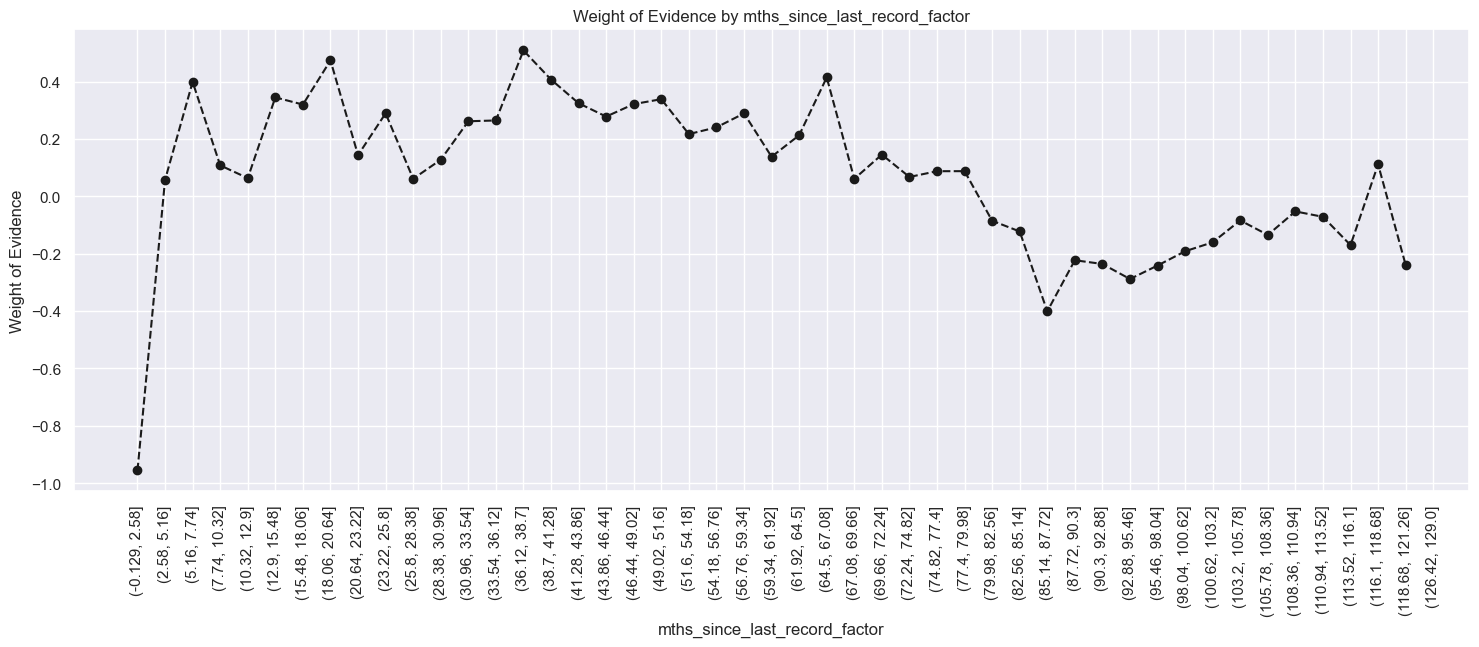

In [171]:
plot_by_woe(df_temp, 90)

In [172]:
df_inputs_prepr['mths_since_last_record:Missing'] = np.where((df_inputs_prepr['mths_since_last_record'].isnull()), 1, 0)
df_inputs_prepr['mths_since_last_record:0-2'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 0) & (df_inputs_prepr['mths_since_last_record'] <= 2), 1, 0)
df_inputs_prepr['mths_since_last_record:3-20'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 3) & (df_inputs_prepr['mths_since_last_record'] <= 20), 1, 0)
df_inputs_prepr['mths_since_last_record:21-31'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 21) & (df_inputs_prepr['mths_since_last_record'] <= 31), 1, 0)
df_inputs_prepr['mths_since_last_record:32-80'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 32) & (df_inputs_prepr['mths_since_last_record'] <= 80), 1, 0)
df_inputs_prepr['mths_since_last_record:81-86'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 81) & (df_inputs_prepr['mths_since_last_record'] <= 86), 1, 0)
df_inputs_prepr['mths_since_last_record:>86'] = np.where((df_inputs_prepr['mths_since_last_record'] > 86), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2222586916.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_record:Missing'] = np.where((df_inputs_prepr['mths_since_last_record'].isnull()), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\2222586916.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_record:0-2'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 0) & (df_inputs_prepr['mths_since_last_record'] <= 2), 1, 0)
C:\Users\kshit\AppData\

In [173]:
df_inputs_prepr_test['mths_since_last_record:Missing'] = np.where((df_inputs_prepr_test['mths_since_last_record'].isnull()), 1, 0)
df_inputs_prepr_test['mths_since_last_record:0-2'] = np.where((df_inputs_prepr_test['mths_since_last_record'] >= 0) & (df_inputs_prepr_test['mths_since_last_record'] <= 2), 1, 0)
df_inputs_prepr_test['mths_since_last_record:3-20'] = np.where((df_inputs_prepr_test['mths_since_last_record'] >= 3) & (df_inputs_prepr_test['mths_since_last_record'] <= 20), 1, 0)
df_inputs_prepr_test['mths_since_last_record:21-31'] = np.where((df_inputs_prepr_test['mths_since_last_record'] >= 21) & (df_inputs_prepr_test['mths_since_last_record'] <= 31), 1, 0)
df_inputs_prepr_test['mths_since_last_record:32-80'] = np.where((df_inputs_prepr_test['mths_since_last_record'] >= 32) & (df_inputs_prepr_test['mths_since_last_record'] <= 80), 1, 0)
df_inputs_prepr_test['mths_since_last_record:81-86'] = np.where((df_inputs_prepr_test['mths_since_last_record'] >= 81) & (df_inputs_prepr_test['mths_since_last_record'] <= 86), 1, 0)
df_inputs_prepr_test['mths_since_last_record:>86'] = np.where((df_inputs_prepr_test['mths_since_last_record'] > 86), 1, 0)

C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\843374070.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['mths_since_last_record:Missing'] = np.where((df_inputs_prepr_test['mths_since_last_record'].isnull()), 1, 0)
C:\Users\kshit\AppData\Local\Temp\ipykernel_20204\843374070.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_test['mths_since_last_record:0-2'] = np.where((df_inputs_prepr_test['mths_since_last_record'] >= 0) & (df_inputs_prepr_test['mths_since_last_record'] <= 2), 1, 0)


In [174]:
df_inputs_prepr_test = df_inputs_prepr_test[df_inputs_prepr.columns]

In [175]:
df_inputs_prepr.shape

(373028, 324)

In [176]:
df_inputs_prepr.to_csv('loan_data_inputs_train.csv')
loan_data_targets_train.to_csv('loan_data_targets_train.csv')
df_inputs_prepr_test.to_csv('loan_data_inputs_test.csv')
loan_data_targets_test.to_csv('loan_data_targets_test.csv')